In [1]:
# [SB01] Define data dir, imports, and helpers. Required before anything else.
USE_DRIVE = False  # True only in Colab if you want persistence

if USE_DRIVE:
    from google.colab import drive  # ignore in Jupyter
    drive.mount('/content/drive', force_remount=True)
    DATA_DIR = "/content/drive/MyDrive/statsbomb"
else:
    DATA_DIR = "./statsbomb"

import os, re, time, json, requests, pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

os.makedirs(DATA_DIR, exist_ok=True)

BASE = "https://raw.githubusercontent.com/statsbomb/open-data/master/data"
TOP5 = {"Premier League","La Liga","Bundesliga","Serie A","Ligue 1"}
TARGET_END_YEAR = 2018
PREF = {2016, 2017, 2018}

def fetch_json(path, retries=3, sleep=1.5):
    url = f"{BASE}/{path}"
    for i in range(retries):
        r = requests.get(url, timeout=60)
        if r.ok:
            return r.json()
        time.sleep(sleep*(2**i))
    r.raise_for_status()

def save_json(obj, path):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False)

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

print("Ready. DATA_DIR =", DATA_DIR)


Ready. DATA_DIR = ./statsbomb


In [2]:
# [SB02] Load competitions and derive season end-year.
comps = fetch_json("competitions.json")
comp_df = pd.DataFrame(comps)

def season_end_year(s):
    m = re.match(r"(\d{4})/(\d{4})", str(s))
    return int(m.group(2)) if m else None

comp_df["end_year"] = comp_df["season_name"].map(season_end_year)
top5_df = comp_df[comp_df["competition_name"].isin(TOP5)].copy()
top5_df = top5_df.sort_values(["competition_name","end_year"]).reset_index(drop=True)
print("Rows in top-5:", len(top5_df))
top5_df.head(8)


Rows in top-5: 25


,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available,end_year
0,11,278,Spain,La Liga,male,False,False,1973/1974,2023-07-06T12:50:48.807820,None,None,2023-07-06T12:50:48.807820,1974.0
1,11,37,Spain,La Liga,male,False,False,2004/2005,2025-06-24T13:48:43.998096,2021-06-13T16:17:31.694,None,2025-06-24T13:48:43.998096,2005.0
2,11,38,Spain,La Liga,male,False,False,2005/2006,2025-06-24T14:05:07.849675,2021-06-13T16:17:31.694,None,2025-06-24T14:05:07.849675,2006.0
3,11,39,Spain,La Liga,male,False,False,2006/2007,2025-06-24T13:52:50.824119,2021-06-13T16:17:31.694,None,2025-06-24T13:52:50.824119,2007.0
4,11,40,Spain,La Liga,male,False,False,2007/2008,2025-06-24T13:47:07.137835,2021-06-13T16:17:31.694,None,2025-06-24T13:47:07.137835,2008.0
5,11,41,Spain,La Liga,male,False,False,2008/2009,2025-06-24T13:52:04.679206,2021-06-13T16:17:31.694,None,2025-06-24T13:52:04.679206,2009.0
6,11,21,Spain,La Liga,male,False,False,2009/2010,2025-06-24T13:43:36.379754,2021-06-13T16:17:31.694,None,2025-06-24T13:43:36.379754,2010.0
7,11,22,Spain,La Liga,male,False,False,2010/2011,2025-06-24T13:51:54.910296,2021-06-13T16:17:31.694,None,2025-06-24T13:51:54.910296,2011.0


In [3]:
# [SB03] Check availability to avoid empty selections later.
available = (
    top5_df.groupby("competition_name")["end_year"]
    .apply(lambda s: sorted(set(int(x) for x in s.dropna())))
    .to_dict()
)
print("End-years by league:", available)


End-years by league: {'La Liga': [1974, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021], 'Ligue 1': [2016, 2022, 2023], 'Premier League': [2004, 2016], 'Serie A': [1987, 2016]}


In [4]:
# [SB04] Select a PL season ending 2018 if present, else nearest <=2018, else nearest overall.
pl = top5_df[top5_df["competition_name"]=="Premier League"].copy()
if pl.empty:
    raise ValueError("Premier League not found in competitions.json")

pl_target = pl.loc[pl["end_year"]==2018]
if pl_target.empty:
    le = pl.loc[pl["end_year"]<=2018]
    pl_target = le.tail(1) if not le.empty else pl.tail(1)

PL_COMP_ID = int(pl_target["competition_id"].iloc[0])
PL_SEASON_ID = int(pl_target["season_id"].iloc[0])
PL_SEASON_NAME = pl_target["season_name"].iloc[0]
print({"competition_id": PL_COMP_ID, "season_id": PL_SEASON_ID, "season_name": PL_SEASON_NAME})


{'competition_id': 2, 'season_id': 27, 'season_name': '2015/2016'}


In [5]:
# [SB04A] Assert required variables exist before downloads.
for name in ["DATA_DIR","PL_COMP_ID","PL_SEASON_ID","PL_SEASON_NAME"]:
    if name not in globals():
        raise NameError(f"{name} is not defined. Run cells SB01–SB04 first.")
print("Guards OK.")


Guards OK.


In [6]:
# [SB05] Cache matches for the chosen PL season.
matches_path = f"{DATA_DIR}/matches/{PL_COMP_ID}/{PL_SEASON_ID}.json"
if not Path(matches_path).exists():
    matches = fetch_json(f"matches/{PL_COMP_ID}/{PL_SEASON_ID}.json")
    save_json(matches, matches_path)
else:
    matches = load_json(matches_path)

print("PL matches:", len(matches))
print("Sample keys:", list(matches[0].keys()) if matches else "None")


PL matches: 380
Sample keys: ['match_id', 'match_date', 'kick_off', 'competition', 'season', 'home_team', 'away_team', 'home_score', 'away_score', 'match_status', 'match_status_360', 'last_updated', 'last_updated_360', 'metadata', 'match_week', 'competition_stage', 'stadium', 'referee']


In [7]:
# [SB06] Helper to cache events per match.
EVENTS_DIR = f"{DATA_DIR}/events"
os.makedirs(EVENTS_DIR, exist_ok=True)

def get_events_for_match(mid, overwrite=False, pause=0.25):
    out = f"{EVENTS_DIR}/{mid}.json"
    if Path(out).exists() and not overwrite:
        return load_json(out)
    data = fetch_json(f"events/{mid}.json")
    save_json(data, out)
    time.sleep(pause)
    return data

print("Events dir:", EVENTS_DIR)


Events dir: ./statsbomb/events


In [8]:
# [SB07] Download a subset first to validate pipeline.
match_ids = [m["match_id"] for m in matches]
print("Total PL matches:", len(match_ids))

subset = match_ids[:20]
for mid in tqdm(subset, desc="PL subset events"):
    _ = get_events_for_match(mid)

# Full season when ready:
# for mid in tqdm(match_ids, desc="PL all events"):
#     _ = get_events_for_match(mid)


Total PL matches: 380


PL subset events:   0%|          | 0/20 [00:00<?, ?it/s]

In [9]:
# [SB08] Aggregate cached PL events into one file for the assignment.
agg = []
for mid in tqdm(match_ids, desc="Aggregate PL events"):
    p = f"{EVENTS_DIR}/{mid}.json"
    if Path(p).exists():
        agg.append(load_json(p))

bundle = {
    "competition_name": "Premier League",
    "season_name": PL_SEASON_NAME,
    "competition_id": PL_COMP_ID,
    "season_id": PL_SEASON_ID,
    "matches": match_ids,
    "events_per_match": agg,
}
out_path = f"{DATA_DIR}/events_England.json"
save_json(bundle, out_path)
print("Wrote:", out_path, "bytes:", Path(out_path).stat().st_size if Path(out_path).exists() else 0)


Aggregate PL events:   0%|          | 0/380 [00:00<?, ?it/s]

Wrote: ./statsbomb/events_England.json bytes: 45973186


In [10]:
# [SB09] Choose one non-PL league near 2018 with empties handled.
def rank_key(end_year):
    if pd.isna(end_year): 
        return (1, 10**6, 0)
    e = int(end_year)
    return (0 if e in PREF else 1, abs(e-TARGET_END_YEAR), -e)

def pick_season_safe(df, league):
    d = df[df["competition_name"]==league].copy()
    if d.empty:
        return None
    d["rk"] = d["end_year"].map(rank_key)
    d = d.sort_values("rk")
    if d.empty:
        return None
    row = d.iloc[0]
    return int(row["competition_id"]), int(row["season_id"]), row["season_name"]

other = {}
for league in sorted(TOP5 - {"Premier League"}):
    sel = pick_season_safe(top5_df, league)
    if sel: other[league] = dict(zip(["competition_id","season_id","season_name"], sel))

print("Selected non-PL:", other)


Selected non-PL: {'La Liga': {'competition_id': 11, 'season_id': 1, 'season_name': '2017/2018'}, 'Ligue 1': {'competition_id': 7, 'season_id': 27, 'season_name': '2015/2016'}, 'Serie A': {'competition_id': 12, 'season_id': 27, 'season_name': '2015/2016'}}


In [11]:
# [SB10] Pull a small subset for one non-PL league.
LEAGUE = next(iter(other)) if other else None
if LEAGUE is None:
    print("No non-PL leagues available. Check SB03.")
else:
    cid = other[LEAGUE]["competition_id"]
    sid = other[LEAGUE]["season_id"]
    sname = other[LEAGUE]["season_name"]

    mm_path = f"{DATA_DIR}/matches/{cid}/{sid}.json"
    if not Path(mm_path).exists():
        mm = fetch_json(f"matches/{cid}/{sid}.json")
        save_json(mm, mm_path)
    else:
        mm = load_json(mm_path)

    mids = [m["match_id"] for m in mm]
    for mid in tqdm(mids[:20], desc=f"{LEAGUE} subset events"):
        _ = get_events_for_match(mid)

    print(f"{LEAGUE} {sname} matches:", len(mids))


La Liga subset events:   0%|          | 0/20 [00:00<?, ?it/s]

La Liga 2017/2018 matches: 36


In [12]:
# [NB11F] Rebuild flat events with match_id injected from filenames
import pandas as pd, numpy as np
from pathlib import Path

files = sorted(Path(EVENTS_DIR).glob("*.json"))
assert files, "[NB11F] No events cached. Run NB07 first."

rows = []
for fp in files:
    mid = int(fp.stem)  # filename "12345.json" -> 12345
    evs = load_json(fp)
    for e in evs:
        e = dict(e)              # shallow copy
        e["match_id"] = mid      # inject match_id
        rows.append(e)

events = pd.json_normalize(rows, sep="_")
print(f"[NB11F] OK: events rows={len(events)} cols={len(events.columns)} has_match_id={'match_id' in events.columns}")


[NB11F] OK: events rows=144527 cols=141 has_match_id=True


In [13]:
# [NB12F] Create passes table with geometry + safe column selection
import numpy as np

passes = events[events.get("type_name","")=="Pass"].copy()

# start and end points
passes["x"] = passes["location"].apply(lambda v: v[0] if isinstance(v, list) and len(v)>=2 else np.nan)
passes["y"] = passes["location"].apply(lambda v: v[1] if isinstance(v, list) and len(v)>=2 else np.nan)
passes["end_x"] = passes["pass_end_location"].apply(lambda v: v[0] if isinstance(v, list) and len(v)>=2 else np.nan)
passes["end_y"] = passes["pass_end_location"].apply(lambda v: v[1] if isinstance(v, list) and len(v)>=2 else np.nan)

# features
dx = passes["end_x"] - passes["x"]
dy = passes["end_y"] - passes["y"]
passes["dist"] = np.hypot(dx, dy)
passes["angle"] = np.degrees(np.arctan2(dy, dx))
passes["forward"] = (dx > 0).astype(int)
passes["height_low"] = (passes.get("pass_height_name","")== "Low Pass").astype(int)
passes["height_high"] = (passes.get("pass_height_name","")== "High Pass").astype(int)
passes["body_part_foot"] = (passes.get("pass_body_part_name","")== "Foot").astype(int)

# choose keepable columns that actually exist
requested = [
    "id","match_id","team_name","player_name","minute","second",
    "x","y","end_x","end_y","dist","angle","forward",
    "height_low","height_high","body_part_foot",
    "possession","possession_team_name"
]
keep = [c for c in requested if c in passes.columns]
passes = passes[keep].dropna(subset=["x","y","end_x","end_y"])
print(f"[NB12F] OK: passes rows={len(passes)} kept_cols={len(keep)} missing={[c for c in requested if c not in keep]}")


[NB12F] OK: passes rows=40609 kept_cols=18 missing=[]


In [14]:
# [NB13] Create binary target for ML: shot within 10s in same possession
shots = events[events["type_name"]=="Shot"][["match_id","possession","minute","second"]].copy()
shots["t"] = shots["minute"]*60 + shots["second"]

p = passes.copy()
p["t"] = p["minute"]*60 + p["second"]
key_cols = ["match_id","possession"]

# next shot time per possession
next_shot = (shots
             .sort_values(["match_id","possession","t"])
             .groupby(key_cols)["t"]
             .min()
             .reset_index()
             .rename(columns={"t":"t_shot"}))

p = p.merge(next_shot, on=key_cols, how="left")
p["label_shot10"] = ((~p["t_shot"].isna()) & ((p["t_shot"] - p["t"])>=0) & ((p["t_shot"] - p["t"])<=10)).astype(int)

pos_rate = p["label_shot10"].mean() if len(p) else float("nan")
print(f"[NB13] OK: labels built. positive_rate={pos_rate:.4f}, rows={len(p)}")


[NB13] OK: labels built. positive_rate=0.0545, rows=40609


In [15]:
# [NB14] Fit logistic regression: features -> P(shot within 10s)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

feat_cols = ["x","y","end_x","end_y","dist","angle","forward","height_low","height_high","body_part_foot"]
df = p.dropna(subset=feat_cols).copy()
X = df[feat_cols].values
y = df["label_shot10"].values

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
pipe = Pipeline([("scaler", StandardScaler(with_mean=False)), ("clf", LogisticRegression(max_iter=1000))])
pipe.fit(Xtr, ytr)
probs = pipe.predict_proba(Xte)[:,1]
auc = roc_auc_score(yte, probs)
ap = average_precision_score(yte, probs)
print(f"[NB14] OK: model trained. ROC-AUC={auc:.3f} AP={ap:.3f} n_train={len(Xtr)} n_test={len(Xte)}")


[NB14] OK: model trained. ROC-AUC=0.775 AP=0.155 n_train=32487 n_test=8122


In [16]:
# [NB15] Rank players: mean predicted probability of their passes
df["prob"] = pipe.predict_proba(df[feat_cols].values)[:,1]
player_rank = (df.groupby("player_name")["prob"]
               .agg(["count","mean"])
               .rename(columns={"count":"passes","mean":"pass_danger"})
               .sort_values("pass_danger", ascending=False))
top10 = player_rank.query("passes >= 200").head(10) if "passes" in player_rank else player_rank.head(10)
print("[NB15] OK: ranking computed. Top rows:")
print(top10)


[NB15] OK: ranking computed. Top rows:
                                  passes  pass_danger
player_name                                          
Ousmane Dembélé                      255     0.103863
Lionel Andrés Messi Cuccittini      1137     0.099300
Luis Alberto Suárez Díaz             538     0.098119
Philippe Coutinho Correia            585     0.088480
Andrés Iniesta Luján                 799     0.070483
Christian Fuchs                      211     0.068422
Sergi Roberto Carnicer               968     0.058242
Jordi Alba Ramos                    1174     0.057722
Danny Drinkwater                     214     0.055103
José Paulo Bezzera Maciel Júnior     767     0.051963


In [17]:
# [NB16] Score another league's passes with the same model (if you downloaded them)
# Replace 'LEAGUE_MATCH_FILES' with actual cached event files from NB10.
other_files = sorted(Path(EVENTS_DIR).glob("*.json"))
if not other_files:
    print("[NB16] OK: no other league events cached yet. Run NB10 first.")
else:
    rows_o = []
    for fp in other_files[:300]:  # limit during dev
        evs = load_json(fp)
        for e in evs:
            rows_o.append(e)
    ev_o = pd.json_normalize(rows_o, sep="_")
    pass_o = ev_o[ev_o["type_name"]=="Pass"].copy()
    for col, f in [("x","location"),("y","location"),("end_x","pass_end_location"),("end_y","pass_end_location")]:
        if col in ["x","y"]:
            pass_o[col] = pass_o[f].apply(lambda v: v[0] if isinstance(v, list) and len(v)>=2 else np.nan) if col=="x" else pass_o[f].apply(lambda v: v[1] if isinstance(v, list) and len(v)>=2 else np.nan)
        else:
            pass_o[col] = pass_o[f].apply(lambda v: v[0] if isinstance(v, list) and len(v)>=2 else np.nan) if col=="end_x" else pass_o[f].apply(lambda v: v[1] if isinstance(v, list) and len(v)>=2 else np.nan)
    pass_o["dist"] = np.hypot(pass_o["end_x"]-pass_o["x"], pass_o["end_y"]-pass_o["y"])
    pass_o["angle"] = np.degrees(np.arctan2(pass_o["end_y"]-pass_o["y"], pass_o["end_x"]-pass_o["x"]))
    pass_o["forward"] = (pass_o["end_x"] - pass_o["x"] > 0).astype(int)
    pass_o["height_low"] = (pass_o["pass_height_name"]=="Low Pass").astype(int)
    pass_o["height_high"] = (pass_o["pass_height_name"]=="High Pass").astype(int)
    pass_o["body_part_foot"] = (pass_o["pass_body_part_name"]=="Foot").astype(int)

    pass_o = pass_o.dropna(subset=feat_cols)
    if len(pass_o)==0:
        print("[NB16] OK: other league has no usable passes in sample.")
    else:
        pass_o["prob"] = pipe.predict_proba(pass_o[feat_cols].values)[:,1]
        rank_o = (pass_o.groupby("player_name")["prob"]
                  .agg(["count","mean"])
                  .rename(columns={"count":"passes","mean":"pass_danger"})
                  .sort_values("pass_danger", ascending=False))
        top_o = rank_o.query("passes >= 200").head(10) if "passes" in rank_o else rank_o.head(10)
        print("[NB16] OK: other-league ranking computed. Top rows:")
        print(top_o)


[NB16] OK: other-league ranking computed. Top rows:
                                  passes  pass_danger
player_name                                          
Ousmane Dembélé                      255     0.103863
Lionel Andrés Messi Cuccittini      1137     0.099300
Luis Alberto Suárez Díaz             538     0.098119
Philippe Coutinho Correia            585     0.088480
Andrés Iniesta Luján                 799     0.070483
Christian Fuchs                      211     0.068422
Sergi Roberto Carnicer               968     0.058242
Jordi Alba Ramos                    1174     0.057722
Danny Drinkwater                     214     0.055103
José Paulo Bezzera Maciel Júnior     767     0.051963


In [18]:
# [NB16F] Write CSVs for deliverables
out_dir = Path(DATA_DIR) / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)
player_rank.to_csv(out_dir / "pl_player_pass_danger.csv")
df[["player_name","team_name","prob","dist","angle","forward"]].to_csv(out_dir / "pl_scored_passes_sample.csv", index=False)
print(f"[NB16F] OK: wrote {out_dir/'pl_player_pass_danger.csv'} and pl_scored_passes_sample.csv")


[NB16F] OK: wrote statsbomb\outputs\pl_player_pass_danger.csv and pl_scored_passes_sample.csv


In [19]:
# [NB15] Rank PL players; require volume to reduce noise
import pandas as pd

MIN_PASSES = 200
df["prob"] = pipe.predict_proba(df[feat_cols].values)[:,1]
player_rank = (df.groupby("player_name")["prob"]
               .agg(passes="count", pass_danger="mean")
               .sort_values("pass_danger", ascending=False))
topN = player_rank.query("passes >= @MIN_PASSES").head(15)
print(f"[NB15] OK: ranked {len(player_rank)} players. Showing top 15 with >= {MIN_PASSES} passes:\n")
print(topN)


[NB15] OK: ranked 535 players. Showing top 15 with >= 200 passes:

                                  passes  pass_danger
player_name                                          
Ousmane Dembélé                      255     0.103863
Lionel Andrés Messi Cuccittini      1137     0.099300
Luis Alberto Suárez Díaz             538     0.098119
Philippe Coutinho Correia            585     0.088480
Andrés Iniesta Luján                 799     0.070483
Christian Fuchs                      211     0.068422
Sergi Roberto Carnicer               968     0.058242
Jordi Alba Ramos                    1174     0.057722
Danny Drinkwater                     214     0.055103
José Paulo Bezzera Maciel Júnior     767     0.051963
Lucas Digne                          251     0.051811
Ivan Rakitić                        1257     0.050509
Nélson Cabral Semedo                 664     0.049195
Erik Pieters                         232     0.043011
Sergio Busquets i Burgos            1149     0.040582


In [20]:
# [NB16] Write CSVs you can cite in the write-up
from pathlib import Path
out_dir = Path(DATA_DIR) / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)
player_rank.to_csv(out_dir / "pl_player_pass_danger.csv")
df.sample(1000, random_state=0)[["player_name","team_name","prob","dist","angle","forward"]].to_csv(
    out_dir / "pl_scored_passes_sample.csv", index=False
)
print(f"[NB16] OK: wrote {out_dir/'pl_player_pass_danger.csv'} and pl_scored_passes_sample.csv")


[NB16] OK: wrote statsbomb\outputs\pl_player_pass_danger.csv and pl_scored_passes_sample.csv


In [21]:
# [NB17] Inspect feature coefficients for sanity
coef = getattr(pipe.named_steps["clf"], "coef_", None)
if coef is None:
    print("[NB17] ERROR: no coefficients found")
else:
    coef_map = pd.Series(coef.ravel(), index=feat_cols).sort_values(ascending=False)
    print("[NB17] OK: feature coefficients (desc):\n")
    print(coef_map)


[NB17] OK: feature coefficients (desc):

end_x             0.724169
x                 0.662924
forward           0.125263
dist              0.110007
y                 0.028114
body_part_foot    0.000000
angle            -0.021755
end_y            -0.079840
height_low       -0.117403
height_high      -0.195573
dtype: float64


In [22]:
# [NB19] Pick a non-PL league near 2018 and cache its events into ./statsbomb/events_other
from pathlib import Path
import numpy as np

print("[NB19] START")

# 1) pick league safely
def rank_key(end_year):
    if pd.isna(end_year): 
        return (1, 10**6, 0)
    e = int(end_year)
    return (0 if e in PREF else 1, abs(e-TARGET_END_YEAR), -e)

candidates = []
for lg in sorted({"La Liga","Bundesliga","Serie A","Ligue 1"}):
    df_l = top5_df[top5_df["competition_name"]==lg].copy()
    if df_l.empty: 
        continue
    df_l["rk"] = df_l["end_year"].map(rank_key)
    row = df_l.sort_values("rk").head(1)
    if not row.empty:
        cid = int(row["competition_id"].iloc[0])
        sid = int(row["season_id"].iloc[0])
        sname = row["season_name"].iloc[0]
        candidates.append((lg, cid, sid, sname))

if not candidates:
    print("[NB19] ERROR: no non-PL league available")
else:
    # choose the first candidate
    LEAGUE, CID, SID, SNAME = candidates[0]
    print(f"[NB19] Selected: {LEAGUE} {SNAME} (comp_id={CID}, season_id={SID})")

    # 2) download matches
    matches_other_path = f"{DATA_DIR}/matches/{CID}/{SID}.json"
    if not Path(matches_other_path).exists():
        mm = fetch_json(f"matches/{CID}/{SID}.json")
        save_json(mm, matches_other_path)
        src = "downloaded"
    else:
        mm = load_json(matches_other_path)
        src = "cached"
    print(f"[NB19] matches {src}: count={len(mm)} path={matches_other_path}")

    # 3) events cache dir for other league
    OTHER_EVENTS_DIR = "./statsbomb/events_other"
    Path(OTHER_EVENTS_DIR).mkdir(parents=True, exist_ok=True)
    print(f"[NB19] events dir: {OTHER_EVENTS_DIR}")

    # 4) download subset first, then you can scale up
    mids = [m["match_id"] for m in mm]
    subset = mids[:20]
    miss, got = 0, 0
    for mid in tqdm(subset, desc="[NB19] subset other events"):
        out = f"{OTHER_EVENTS_DIR}/{mid}.json"
        if not Path(out).exists():
            data = fetch_json(f"events/{mid}.json")
            save_json(data, out)
            got += 1
        else:
            got += 1
    print(f"[NB19] OK: fetched_or_cached={got} subset={len(subset)} league={LEAGUE} season={SNAME}")

    # Uncomment to fetch all matches after verifying subset works
    # for mid in tqdm(mids, desc="[NB19] all other events"):
    #     out = f"{OTHER_EVENTS_DIR}/{mid}.json"
    #     if not Path(out).exists():
    #         save_json(fetch_json(f"events/{mid}.json"), out)

print("[NB19] DONE")


[NB19] START
[NB19] Selected: La Liga 2017/2018 (comp_id=11, season_id=1)
[NB19] matches cached: count=36 path=./statsbomb/matches/11/1.json
[NB19] events dir: ./statsbomb/events_other


[NB19] subset other events:   0%|          | 0/20 [00:00<?, ?it/s]

[NB19] OK: fetched_or_cached=20 subset=20 league=La Liga season=2017/2018
[NB19] DONE


In [23]:
# [NB18] Score another league's cached events in a separate folder
# 1) Set OTHER_EVENTS_DIR to where you cached non-PL events (e.g., "./statsbomb/events_la_liga")
# 2) Reuse the trained PL model to rank players there.

from pathlib import Path
import numpy as np

OTHER_EVENTS_DIR = "./statsbomb/events_other"  # change to your non-PL events dir
if not Path(OTHER_EVENTS_DIR).exists():
    print(f"[NB18] OK: set OTHER_EVENTS_DIR to your non-PL cache. Current missing: {OTHER_EVENTS_DIR}")
else:
    files_o = sorted(Path(OTHER_EVENTS_DIR).glob("*.json"))
    if not files_o:
        print(f"[NB18] OK: no files in {OTHER_EVENTS_DIR}")
    else:
        rows_o = []
        for fp in files_o:
            mid = int(Path(fp).stem)
            evs = load_json(fp)
            for e in evs:
                e = dict(e); e["match_id"] = mid
                rows_o.append(e)
        ev_o = pd.json_normalize(rows_o, sep="_")
        pass_o = ev_o[ev_o["type_name"]=="Pass"].copy()
        pass_o["x"] = pass_o["location"].apply(lambda v: v[0] if isinstance(v, list) and len(v)>=2 else np.nan)
        pass_o["y"] = pass_o["location"].apply(lambda v: v[1] if isinstance(v, list) and len(v)>=2 else np.nan)
        pass_o["end_x"] = pass_o["pass_end_location"].apply(lambda v: v[0] if isinstance(v, list) and len(v)>=2 else np.nan)
        pass_o["end_y"] = pass_o["pass_end_location"].apply(lambda v: v[1] if isinstance(v, list) and len(v)>=2 else np.nan)
        pass_o["dist"] = np.hypot(pass_o["end_x"]-pass_o["x"], pass_o["end_y"]-pass_o["y"])
        pass_o["angle"] = np.degrees(np.arctan2(pass_o["end_y"]-pass_o["y"], pass_o["end_x"]-pass_o["x"]))
        pass_o["forward"] = (pass_o["end_x"] - pass_o["x"] > 0).astype(int)
        pass_o["height_low"] = (pass_o["pass_height_name"]=="Low Pass").astype(int)
        pass_o["height_high"] = (pass_o["pass_height_name"]=="High Pass").astype(int)
        pass_o["body_part_foot"] = (pass_o["pass_body_part_name"]=="Foot").astype(int)
        pass_o = pass_o.dropna(subset=feat_cols)
        if len(pass_o)==0:
            print("[NB18] OK: other league has no usable passes after filtering")
        else:
            pass_o["prob"] = pipe.predict_proba(pass_o[feat_cols].values)[:,1]
            rank_o = (pass_o.groupby("player_name")["prob"]
                      .agg(passes="count", pass_danger="mean")
                      .sort_values("pass_danger", ascending=False))
            top_o = rank_o.query("passes >= @MIN_PASSES").head(15)
            out_dir_o = Path(DATA_DIR) / "outputs"
            out_dir_o.mkdir(parents=True, exist_ok=True)
            rank_o.to_csv(out_dir_o / "other_player_pass_danger.csv")
            print(f"[NB18] OK: ranked other league. Top 15 with >= {MIN_PASSES} passes:\n")
            print(top_o)
            print(f"[NB18] OK: wrote {out_dir_o/'other_player_pass_danger.csv'}")
 

[NB18] OK: ranked other league. Top 15 with >= 200 passes:

                                  passes  pass_danger
player_name                                          
Ousmane Dembélé                      255     0.103863
Lionel Andrés Messi Cuccittini      1137     0.099300
Luis Alberto Suárez Díaz             538     0.098119
Philippe Coutinho Correia            533     0.089058
Andrés Iniesta Luján                 799     0.070483
Sergi Roberto Carnicer               968     0.058242
Jordi Alba Ramos                    1174     0.057722
José Paulo Bezzera Maciel Júnior     767     0.051963
Lucas Digne                          251     0.051811
Ivan Rakitić                        1257     0.050509
Nélson Cabral Semedo                 664     0.049195
Sergio Busquets i Burgos            1149     0.040582
Samuel Yves Umtiti                   816     0.024984
Javier Alejandro Mascherano          270     0.024856
Thomas Vermaelen                     377     0.022209
[NB18] OK: wrote stats

In [24]:
# [NB19] Pick a non-PL league near 2018 and cache its events into ./statsbomb/events_other
from pathlib import Path
import numpy as np

print("[NB19] START")

# 1) pick league safely
def rank_key(end_year):
    if pd.isna(end_year): 
        return (1, 10**6, 0)
    e = int(end_year)
    return (0 if e in PREF else 1, abs(e-TARGET_END_YEAR), -e)

candidates = []
for lg in sorted({"La Liga","Bundesliga","Serie A","Ligue 1"}):
    df_l = top5_df[top5_df["competition_name"]==lg].copy()
    if df_l.empty: 
        continue
    df_l["rk"] = df_l["end_year"].map(rank_key)
    row = df_l.sort_values("rk").head(1)
    if not row.empty:
        cid = int(row["competition_id"].iloc[0])
        sid = int(row["season_id"].iloc[0])
        sname = row["season_name"].iloc[0]
        candidates.append((lg, cid, sid, sname))

if not candidates:
    print("[NB19] ERROR: no non-PL league available")
else:
    # choose the first candidate
    LEAGUE, CID, SID, SNAME = candidates[0]
    print(f"[NB19] Selected: {LEAGUE} {SNAME} (comp_id={CID}, season_id={SID})")

    # 2) download matches
    matches_other_path = f"{DATA_DIR}/matches/{CID}/{SID}.json"
    if not Path(matches_other_path).exists():
        mm = fetch_json(f"matches/{CID}/{SID}.json")
        save_json(mm, matches_other_path)
        src = "downloaded"
    else:
        mm = load_json(matches_other_path)
        src = "cached"
    print(f"[NB19] matches {src}: count={len(mm)} path={matches_other_path}")

    # 3) events cache dir for other league
    OTHER_EVENTS_DIR = "./statsbomb/events_other"
    Path(OTHER_EVENTS_DIR).mkdir(parents=True, exist_ok=True)
    print(f"[NB19] events dir: {OTHER_EVENTS_DIR}")

    # 4) download subset first, then you can scale up
    mids = [m["match_id"] for m in mm]
    subset = mids[:20]
    miss, got = 0, 0
    for mid in tqdm(subset, desc="[NB19] subset other events"):
        out = f"{OTHER_EVENTS_DIR}/{mid}.json"
        if not Path(out).exists():
            data = fetch_json(f"events/{mid}.json")
            save_json(data, out)
            got += 1
        else:
            got += 1
    print(f"[NB19] OK: fetched_or_cached={got} subset={len(subset)} league={LEAGUE} season={SNAME}")

    # Uncomment to fetch all matches after verifying subset works
    # for mid in tqdm(mids, desc="[NB19] all other events"):
    #     out = f"{OTHER_EVENTS_DIR}/{mid}.json"
    #     if not Path(out).exists():
    #         save_json(fetch_json(f"events/{mid}.json"), out)

print("[NB19] DONE")


[NB19] START
[NB19] Selected: La Liga 2017/2018 (comp_id=11, season_id=1)
[NB19] matches cached: count=36 path=./statsbomb/matches/11/1.json
[NB19] events dir: ./statsbomb/events_other


[NB19] subset other events:   0%|          | 0/20 [00:00<?, ?it/s]

[NB19] OK: fetched_or_cached=20 subset=20 league=La Liga season=2017/2018
[NB19] DONE


In [25]:
# [NB20] Point NB18 to the populated folder and score
OTHER_EVENTS_DIR = "./statsbomb/events_other"
print(f"[NB20] Using OTHER_EVENTS_DIR={OTHER_EVENTS_DIR}")
# Reuse NB18 cell now. It will print top players and write CSV.


[NB20] Using OTHER_EVENTS_DIR=./statsbomb/events_other


In [26]:
# [NB20F] Score ./statsbomb/events_other with the trained PL model and export rankings
from pathlib import Path
import numpy as np
import pandas as pd

print("[NB20F] START")
OTHER_EVENTS_DIR = "./statsbomb/events_other"
MIN_PASSES = 200  # lower if dataset is small, e.g., 100

# 1) Load events, inject match_id
files_o = sorted(Path(OTHER_EVENTS_DIR).glob("*.json"))
if not files_o:
    raise RuntimeError("[NB20F] No files found in OTHER_EVENTS_DIR")
rows_o = []
for fp in files_o:
    mid = int(Path(fp).stem)
    evs = load_json(fp)
    for e in evs:
        e = dict(e); e["match_id"] = mid
        rows_o.append(e)
ev_o = pd.json_normalize(rows_o, sep="_")
print(f"[NB20F] OK: raw events rows={len(ev_o)} files={len(files_o)}")

# 2) Build pass feature table
pass_o = ev_o[ev_o["type_name"]=="Pass"].copy()
pass_o["x"] = pass_o["location"].apply(lambda v: v[0] if isinstance(v, list) and len(v)>=2 else np.nan)
pass_o["y"] = pass_o["location"].apply(lambda v: v[1] if isinstance(v, list) and len(v)>=2 else np.nan)
pass_o["end_x"] = pass_o["pass_end_location"].apply(lambda v: v[0] if isinstance(v, list) and len(v)>=2 else np.nan)
pass_o["end_y"] = pass_o["pass_end_location"].apply(lambda v: v[1] if isinstance(v, list) and len(v)>=2 else np.nan)
pass_o["dist"] = np.hypot(pass_o["end_x"]-pass_o["x"], pass_o["end_y"]-pass_o["y"])
pass_o["angle"] = np.degrees(np.arctan2(pass_o["end_y"]-pass_o["y"], pass_o["end_x"]-pass_o["x"]))
pass_o["forward"] = (pass_o["end_x"] - pass_o["x"] > 0).astype(int)
pass_o["height_low"] = (pass_o["pass_height_name"]=="Low Pass").astype(int)
pass_o["height_high"] = (pass_o["pass_height_name"]=="High Pass").astype(int)
pass_o["body_part_foot"] = (pass_o["pass_body_part_name"]=="Foot").astype(int)
feat_cols = ["x","y","end_x","end_y","dist","angle","forward","height_low","height_high","body_part_foot"]
pass_o = pass_o.dropna(subset=feat_cols)
print(f"[NB20F] OK: passes rows={len(pass_o)} usable={pass_o[feat_cols].notna().all(axis=1).sum()}")

# 3) Predict and rank
probs_o = pipe.predict_proba(pass_o[feat_cols].values)[:,1]
pass_o = pass_o.assign(prob=probs_o)
rank_o = (pass_o.groupby("player_name")["prob"]
          .agg(passes="count", pass_danger="mean")
          .sort_values("pass_danger", ascending=False))
top_o = rank_o.query("passes >= @MIN_PASSES").head(15)
print(f"[NB20F] OK: ranked players={len(rank_o)}. Top 15 with >= {MIN_PASSES} passes:\n")
print(top_o if not top_o.empty else rank_o.head(15))

# 4) Export
out_dir = Path(DATA_DIR) / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)
rank_o.to_csv(out_dir / "laliga_player_pass_danger.csv")
print(f"[NB20F] OK: wrote {out_dir/'laliga_player_pass_danger.csv'}")
print("[NB20F] DONE")


[NB20F] START
[NB20F] OK: raw events rows=102723 files=28
[NB20F] OK: passes rows=29059 usable=29059
[NB20F] OK: ranked players=389. Top 15 with >= 200 passes:

                                  passes  pass_danger
player_name                                          
Ousmane Dembélé                      255     0.103863
Lionel Andrés Messi Cuccittini      1137     0.099300
Luis Alberto Suárez Díaz             538     0.098119
Philippe Coutinho Correia            533     0.089058
Andrés Iniesta Luján                 799     0.070483
Sergi Roberto Carnicer               968     0.058242
Jordi Alba Ramos                    1174     0.057722
José Paulo Bezzera Maciel Júnior     767     0.051963
Lucas Digne                          251     0.051811
Ivan Rakitić                        1257     0.050509
Nélson Cabral Semedo                 664     0.049195
Sergio Busquets i Burgos            1149     0.040582
Samuel Yves Umtiti                   816     0.024984
Javier Alejandro Mascherano  

In [27]:
# [NB21F] Recompute PL ranking summary for side-by-side comparison
MIN_PASSES = 200
df["prob"] = pipe.predict_proba(df[feat_cols].values)[:,1]
pl_rank = (df.groupby(["player_name","team_name"])["prob"]
             .agg(passes="count", pass_danger="mean")
             .sort_values("pass_danger", ascending=False))
pl_top = pl_rank.query("passes >= @MIN_PASSES").head(15)
print("[NB21F] OK: PL top 15 (>=200 passes):\n", pl_top)


[NB21F] OK: PL top 15 (>=200 passes):
                                                  passes  pass_danger
player_name                      team_name                          
Ousmane Dembélé                  Barcelona          255     0.103863
Lionel Andrés Messi Cuccittini   Barcelona         1137     0.099300
Luis Alberto Suárez Díaz         Barcelona          538     0.098119
Philippe Coutinho Correia        Barcelona          479     0.089188
Andrés Iniesta Luján             Barcelona          799     0.070483
Christian Fuchs                  Leicester City     211     0.068422
Sergi Roberto Carnicer           Barcelona          968     0.058242
Jordi Alba Ramos                 Barcelona         1174     0.057722
Danny Drinkwater                 Leicester City     214     0.055103
José Paulo Bezzera Maciel Júnior Barcelona          767     0.051963
Lucas Digne                      Barcelona          251     0.051811
Ivan Rakitić                     Barcelona         1257     0.05

In [28]:
# [NB22F] Attach team info to La Liga ranks and build a shortlist
# Rebuild pass_o with team_name for aggregation if needed
from pathlib import Path
rows_o = []
for fp in sorted(Path("./statsbomb/events_other").glob("*.json")):
    mid = int(Path(fp).stem)
    for e in load_json(fp):
        d = dict(e); d["match_id"] = mid
        rows_o.append(d)
ev_o = pd.json_normalize(rows_o, sep="_")

pass_o = ev_o[ev_o["type_name"]=="Pass"].copy()
pass_o["x"] = pass_o["location"].apply(lambda v: v[0] if isinstance(v, list) and len(v)>=2 else np.nan)
pass_o["y"] = pass_o["location"].apply(lambda v: v[1] if isinstance(v, list) and len(v)>=2 else np.nan)
pass_o["end_x"] = pass_o["pass_end_location"].apply(lambda v: v[0] if isinstance(v, list) and len(v)>=2 else np.nan)
pass_o["end_y"] = pass_o["pass_end_location"].apply(lambda v: v[1] if isinstance(v, list) and len(v)>=2 else np.nan)
pass_o["dist"] = np.hypot(pass_o["end_x"]-pass_o["x"], pass_o["end_y"]-pass_o["y"])
pass_o["angle"] = np.degrees(np.arctan2(pass_o["end_y"]-pass_o["y"], pass_o["end_x"]-pass_o["x"]))
pass_o["forward"] = (pass_o["end_x"] - pass_o["x"] > 0).astype(int)
pass_o["height_low"] = (pass_o["pass_height_name"]=="Low Pass").astype(int)
pass_o["height_high"] = (pass_o["pass_height_name"]=="High Pass").astype(int)
pass_o["body_part_foot"] = (pass_o["pass_body_part_name"]=="Foot").astype(int)
pass_o = pass_o.dropna(subset=feat_cols)

pass_o["prob"] = pipe.predict_proba(pass_o[feat_cols].values)[:,1]

laliga_rank = (pass_o.groupby(["player_name","team_name"])["prob"]
               .agg(passes="count", pass_danger="mean")
               .sort_values("pass_danger", ascending=False))

shortlist = laliga_rank.reset_index().query("passes >= 200").head(20)
print("[NB22F] OK: La Liga shortlist (top 20, >=200 passes):\n", shortlist.head(20))


[NB22F] OK: La Liga shortlist (top 20, >=200 passes):
                           player_name  team_name  passes  pass_danger
34                    Ousmane Dembélé  Barcelona     255     0.103863
39     Lionel Andrés Messi Cuccittini  Barcelona    1137     0.099300
43           Luis Alberto Suárez Díaz  Barcelona     538     0.098119
67          Philippe Coutinho Correia  Barcelona     479     0.089188
126              Andrés Iniesta Luján  Barcelona     799     0.070483
180            Sergi Roberto Carnicer  Barcelona     968     0.058242
181                  Jordi Alba Ramos  Barcelona    1174     0.057722
208  José Paulo Bezzera Maciel Júnior  Barcelona     767     0.051963
210                       Lucas Digne  Barcelona     251     0.051811
217                      Ivan Rakitić  Barcelona    1257     0.050509
224              Nélson Cabral Semedo  Barcelona     664     0.049195
260          Sergio Busquets i Burgos  Barcelona    1149     0.040582
310                Samuel Yves Umti

In [29]:
# [NB23F] Normalize by team average to reduce big-team bias
team_avg = (pass_o.groupby("team_name")["prob"]
            .mean()
            .rename("team_pass_avg")
            .reset_index())

ll_detail = (pass_o[["player_name","team_name","prob"]]
             .groupby(["player_name","team_name"])
             .agg(passes=("prob","count"), pass_danger=("prob","mean"))
             .reset_index())

ll_detail = ll_detail.merge(team_avg, on="team_name", how="left")
ll_detail["player_vs_team"] = ll_detail["pass_danger"] / ll_detail["team_pass_avg"]

norm_shortlist = (ll_detail.query("passes >= 200")
                  .sort_values(["player_vs_team","pass_danger"], ascending=False)
                  .head(20))
print("[NB23F] OK: normalized shortlist (top 20, >=200 passes):\n", norm_shortlist.head(20))


[NB23F] OK: normalized shortlist (top 20, >=200 passes):
                           player_name  team_name  passes  pass_danger  \
284                   Ousmane Dembélé  Barcelona     255     0.103863   
228    Lionel Andrés Messi Cuccittini  Barcelona    1137     0.099300   
234          Luis Alberto Suárez Díaz  Barcelona     538     0.098119   
299         Philippe Coutinho Correia  Barcelona     479     0.089188   
25               Andrés Iniesta Luján  Barcelona     799     0.070483   
340            Sergi Roberto Carnicer  Barcelona     968     0.058242   
195                  Jordi Alba Ramos  Barcelona    1174     0.057722   
206  José Paulo Bezzera Maciel Júnior  Barcelona     767     0.051963   
229                       Lucas Digne  Barcelona     251     0.051811   
150                      Ivan Rakitić  Barcelona    1257     0.050509   
280              Nélson Cabral Semedo  Barcelona     664     0.049195   
342          Sergio Busquets i Burgos  Barcelona    1149     0.040

In [30]:
# [NB24F] Save CSVs for write-up and slides
from pathlib import Path
out_dir = Path(DATA_DIR) / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

pl_rank.to_csv(out_dir / "pl_player_pass_danger.csv")
laliga_rank.to_csv(out_dir / "laliga_player_pass_danger_with_team.csv", index=True)
norm_shortlist.to_csv(out_dir / "laliga_shortlist_normalized.csv", index=False)

print(f"[NB24F] OK: wrote\n - {out_dir/'pl_player_pass_danger.csv'}\n - {out_dir/'laliga_player_pass_danger_with_team.csv'}\n - {out_dir/'laliga_shortlist_normalized.csv'}")


[NB24F] OK: wrote
 - statsbomb\outputs\pl_player_pass_danger.csv
 - statsbomb\outputs\laliga_player_pass_danger_with_team.csv
 - statsbomb\outputs\laliga_shortlist_normalized.csv


In [31]:
# [NB25] Plot top players by pass_danger and save PNGs
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path(DATA_DIR) / "outputs"
OUT.mkdir(parents=True, exist_ok=True)

# PL
pl_plot = (pl_rank.reset_index()
           .query("passes >= 200")
           .nlargest(10, "pass_danger"))
plt.figure()
plt.barh(pl_plot["player_name"][::-1], pl_plot["pass_danger"][::-1])
plt.title("Premier League — Pass danger (top 10, >=200 passes)")
plt.tight_layout()
plt.savefig(OUT / "pl_top10_pass_danger.png")
plt.close()

# La Liga
ll_plot = (laliga_rank.reset_index()
           .query("passes >= 200")
           .nlargest(10, "pass_danger"))
plt.figure()
plt.barh(ll_plot["player_name"][::-1], ll_plot["pass_danger"][::-1])
plt.title("La Liga — Pass danger (top 10, >=200 passes)")
plt.tight_layout()
plt.savefig(OUT / "laliga_top10_pass_danger.png")
plt.close()

print(f"[NB25] OK: wrote {OUT/'pl_top10_pass_danger.png'} and {OUT/'laliga_top10_pass_danger.png'}")


[NB25] OK: wrote statsbomb\outputs\pl_top10_pass_danger.png and statsbomb\outputs\laliga_top10_pass_danger.png


In [32]:
# [NB26A] Install python-pptx for slide export
import sys, subprocess
print("[NB26A] START")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "python-pptx"])
print("[NB26A] OK: python-pptx installed")


[NB26A] START
[NB26A] OK: python-pptx installed


In [33]:
# [NB26] Build a minimal 2-slide PPTX with findings and recommendation
from pptx import Presentation
from pptx.util import Inches, Pt
from pathlib import Path

OUT = Path(DATA_DIR) / "outputs"
prs = Presentation()

# Slide 1 — Problem + Metric
s1 = prs.slides.add_slide(prs.slide_layouts[5])
tx = s1.shapes.add_textbox(Inches(0.5), Inches(0.5), Inches(9), Inches(1.5)).text_frame
tx.text = "Assessing Pass Danger for Recruitment (2017/18 context)"
p = tx.add_paragraph(); p.text = "Metric: P(shot within 10s) after a pass — trained on PL, applied cross-league"; p.level = 1
p = tx.add_paragraph(); p.text = "Inputs: start/end coords, distance, angle, forward, height, body part"; p.level = 1
p = tx.add_paragraph(); p.text = "Validation: ROC-AUC and AP reported on held-out PL"; p.level = 1
# Figures
left = Inches(0.5); top = Inches(2.2); height = Inches(2.5)
s1.shapes.add_picture(str(OUT/"pl_top10_pass_danger.png"), left, top, height=height)

# Slide 2 — Shortlist + Recommendation
s2 = prs.slides.add_slide(prs.slide_layouts[5])
tx2 = s2.shapes.add_textbox(Inches(0.5), Inches(0.5), Inches(9), Inches(1.5)).text_frame
tx2.text = "La Liga Shortlist and Recommendation"
p = tx2.add_paragraph(); p.text = "Shortlist: top pass_danger normalized vs team average"; p.level = 1

# Table from normalized shortlist
tbl_data = norm_shortlist.head(8)[["player_name","team_name","passes","pass_danger","player_vs_team"]]
rows, cols = tbl_data.shape
table = s2.shapes.add_table(rows+1, cols, Inches(0.5), Inches(1.8), Inches(9), Inches(2.5)).table
for j,col in enumerate(tbl_data.columns): table.cell(0,j).text = col
for i in range(rows):
    for j in range(cols):
        table.cell(i+1,j).text = str(tbl_data.iloc[i,j])

# Recommendation placeholder
p = tx2.add_paragraph(); p.text = "Recommendation: <Player>, role fit: <why>, risk: <key caveat>"; p.level = 1

pptx_path = OUT / "A2_pass_danger_shortlist.pptx"
prs.save(pptx_path)
print(f"[NB26] OK: wrote {pptx_path}")


[NB26] OK: wrote statsbomb\outputs\A2_pass_danger_shortlist.pptx


In [34]:
# [NB27] Export CSVs used in the write-ups
from pathlib import Path
OUT = Path(DATA_DIR) / "outputs"
pl_rank.reset_index().to_csv(OUT/"pl_player_pass_danger_with_team.csv", index=False)
laliga_rank.reset_index().to_csv(OUT/"laliga_player_pass_danger_with_team.csv", index=False)
norm_shortlist.to_csv(OUT/"laliga_shortlist_normalized.csv", index=False)
print(f"[NB27] OK: wrote CSVs to {OUT}")


[NB27] OK: wrote CSVs to statsbomb\outputs


In [35]:
# [NB28] Create markdown stubs for the non-technical (<=2p) and technical (<=6p) reports
from pathlib import Path
OUT = Path(DATA_DIR) / "outputs"

nontech = OUT / "report_nontechnical.md"
nontech.write_text(
"# Executive Summary\n"
"- Objective: rank pass creators using the probability a pass leads to a shot within 10s.\n"
"- Training data: Premier League season near 2018.\n"
"- Key finding: <top PL player>. Cross-league target: <La Liga player>.\n"
"\n## Assumptions\n"
"- Event locations measured on 120x80 grid.\n"
"- Shots within 10s proxy “danger created.”\n"
"- Team context may inflate big-club players; we normalize vs team mean.\n"
"\n## Recommendation\n"
"- Sign: <Player>. Rationale: role fit, output, age, cost band.\n"
"- Alternative: <Player 2>.\n"
)
tech = OUT / "report_technical.md"
tech.write_text(
"# Data and Label\n"
"- StatsBomb open data. Events for PL training, La Liga for scoring.\n"
"- Label: shot within 10s in same match+possession after pass.\n"
"\n# Features\n"
"- Start/End (x,y), distance, angle, forward flag, pass height, body part.\n"
"\n# Model\n"
"- Logistic regression with standardization. Metrics: ROC-AUC, AP.\n"
"- Coefficients: saved from NB17 for interpretability.\n"
"\n# Validation\n"
"- Split: 80/20 stratified by label. Reported ROC-AUC/AP.\n"
"\n# Deployment\n"
"- Rank by mean predicted P(shot10) per player with min-volume filter.\n"
"- Team normalization: player mean / team mean.\n"
"\n# Caveats\n"
"- Possession chain simplification. No x/y standardization by pitch scaling.\n"
"- Role bias and survivorship bias.\n"
)
print(f"[NB28] OK: wrote {nontech} and {tech}")


[NB28] OK: wrote statsbomb\outputs\report_nontechnical.md and statsbomb\outputs\report_technical.md


#  find the top ranking players in that league (premier)

In [36]:
# [PL01] Bundle Premier League events -> events_England.json
from pathlib import Path
import json

EVENTS_PL_DIR = Path("./statsbomb/events")   # should contain ONLY PL matches
files = sorted(EVENTS_PL_DIR.glob("*.json"))
assert files, "[PL01] ERROR: no PL event files in ./statsbomb/events"

matches, ev_per_match = [], []
for fp in files:
    try:
        mid = int(fp.stem)
    except ValueError:
        print(f"[PL01] WARN skip non-numeric filename {fp.name}"); continue
    evs = json.loads(fp.read_text(encoding="utf-8"))
    if not isinstance(evs, list): 
        print(f"[PL01] WARN skip non-list {fp.name}"); continue
    matches.append(mid); ev_per_match.append(evs)

bundle = {
    "competition_name": "Premier League",
    "season_name": "2017/2018",
    "matches": matches,
    "events_per_match": ev_per_match,
}
Path("events_England.json").write_text(json.dumps(bundle, ensure_ascii=False), encoding="utf-8")
print(f"[PL01] OK: wrote events_England.json matches={len(matches)}")


[PL01] OK: wrote events_England.json matches=40


In [37]:
# [PL02] Train on PL bundle and export PL top list
import json, numpy as np, pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

EVP = Path("events_England.json")
obj = json.loads(EVP.read_text(encoding="utf-8"))
rows=[]
for i, evs in enumerate(obj["events_per_match"]):
    mid = obj["matches"][i]
    for e in evs:
        d = dict(e); d["match_id"]=d.get("match_id", mid); rows.append(d)
events = pd.json_normalize(rows, sep="_")
assert "type_name" in events.columns, "[PL02] ERROR: malformed events"
# passes
def comp(v,i): return v[i] if isinstance(v,list) and len(v)>=2 else np.nan
p = events[events["type_name"]=="Pass"].copy()
p["x"]=p["location"].apply(lambda v: comp(v,0)); p["y"]=p["location"].apply(lambda v: comp(v,1))
p["end_x"]=p["pass_end_location"].apply(lambda v: comp(v,0)); p["end_y"]=p["pass_end_location"].apply(lambda v: comp(v,1))
dx,dy=p["end_x"]-p["x"], p["end_y"]-p["y"]
p["dist"]=np.hypot(dx,dy); p["angle"]=np.degrees(np.arctan2(dy,dx)); p["forward"]=(dx>0).astype(int)
p["height_low"]=(p.get("pass_height_name","")=="Low Pass").astype(int)
p["height_high"]=(p.get("pass_height_name","")=="High Pass").astype(int)
p["body_part_foot"]=(p.get("pass_body_part_name","")=="Foot").astype(int)
p=p.dropna(subset=["x","y","end_x","end_y"])
# label
shots = events[events["type_name"]=="Shot"][["match_id","possession","minute","second"]].copy()
shots["t"]=shots["minute"]*60+shots["second"]
p["t"]=p["minute"]*60+p["second"]
key=["match_id","possession"]
nx=(shots.sort_values(key+["t"]).groupby(key, as_index=False)["t"].min().rename(columns={"t":"t_shot"}))
p=p.merge(nx,on=key,how="left")
p["label_shot10"]=((~p["t_shot"].isna()) & ((p["t_shot"]-p["t"])>=0) & ((p["t_shot"]-p["t"])<=10)).astype(int)
# model
feat_cols=["x","y","end_x","end_y","dist","angle","forward","height_low","height_high","body_part_foot"]
df=p.dropna(subset=feat_cols).copy()
X,y=df[feat_cols].values, df["label_shot10"].values
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
pipe=Pipeline([("scaler",StandardScaler(with_mean=False)),("clf",LogisticRegression(max_iter=1000,random_state=42))])
pipe.fit(Xtr,ytr); probs=pipe.predict_proba(Xte)[:,1]
print(f"[PL02] OK: ROC-AUC={roc_auc_score(yte,probs):.3f} AP={average_precision_score(yte,probs):.3f}")
# rank
df["prob"]=pipe.predict_proba(df[feat_cols].values)[:,1]
player_rank=(df.groupby("player_name")["prob"].agg(passes="count",pass_danger="mean")
               .sort_values("pass_danger",ascending=False))
MIN_PASSES=200
pl_top=(player_rank.reset_index().query("passes>=@MIN_PASSES").nlargest(15,"pass_danger"))
from pathlib import Path
OUT=Path("./outputs"); OUT.mkdir(parents=True, exist_ok=True)
player_rank.to_csv(OUT/"pl_player_pass_danger.csv", index=True)
pl_top.to_csv(OUT/f"pl_top15_min{MIN_PASSES}.csv", index=False)
print(f"[PL02] OK: top15 saved -> {OUT/f'pl_top15_min{MIN_PASSES}.csv'}")
print(pl_top)


[PL02] OK: ROC-AUC=0.775 AP=0.155
[PL02] OK: top15 saved -> outputs\pl_top15_min200.csv
                          player_name  passes  pass_danger
48                    Ousmane Dembélé     255     0.103863
56     Lionel Andrés Messi Cuccittini    1137     0.099300
62           Luis Alberto Suárez Díaz     538     0.098119
95          Philippe Coutinho Correia     585     0.088480
179              Andrés Iniesta Luján     799     0.070483
187                   Christian Fuchs     211     0.068422
257            Sergi Roberto Carnicer     968     0.058242
260                  Jordi Alba Ramos    1174     0.057722
272                  Danny Drinkwater     214     0.055103
297  José Paulo Bezzera Maciel Júnior     767     0.051963
299                       Lucas Digne     251     0.051811
305                      Ivan Rakitić    1257     0.050509
313              Nélson Cabral Semedo     664     0.049195
345                      Erik Pieters     232     0.043011
360          Sergio Busquet

In [38]:
# [PL03] Verify teams look like 2017/18 PL clubs
PL17 = {
 "Arsenal","Bournemouth","Brighton and Hove Albion","Burnley","Chelsea","Crystal Palace","Everton",
 "Huddersfield Town","Leicester City","Liverpool","Manchester City","Manchester United","Newcastle United",
 "Southampton","Stoke City","Swansea City","Tottenham Hotspur","Watford","West Bromwich Albion","West Ham United"
}
teams = set(df["team_name"].dropna().unique()) if "team_name" in df.columns else set()
offenders = sorted(t for t in teams if t not in PL17)
print(f"[PL03] OK: teams={len(teams)} offenders={len(offenders)}")
if offenders:
    print("[PL03] NON-PL TEAM NAMES FOUND:", offenders[:15])
    print("Fix: ensure ./statsbomb/events contains only PL matches, then re-run PL01→PL02.")


[PL03] OK: teams=31 offenders=18
[PL03] NON-PL TEAM NAMES FOUND: ['AFC Bournemouth', 'Aston Villa', 'Athletic Club', 'Barcelona', 'Celta Vigo', 'Eibar', 'Espanyol', 'Las Palmas', 'Leganés', 'Levante UD', 'Norwich City', 'RC Deportivo La Coruña', 'Real Betis', 'Real Madrid', 'Sevilla']
Fix: ensure ./statsbomb/events contains only PL matches, then re-run PL01→PL02.


In [39]:
# [PLFIX1] Move non-PL matches out of ./statsbomb/events into ./statsbomb/events_other
from pathlib import Path
import json, shutil

EVENTS_DIR = Path("./statsbomb/events")
OTHER_DIR  = Path("./statsbomb/events_other"); OTHER_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_DIR  = Path("./statsbomb/events_pl_clean"); CLEAN_DIR.mkdir(parents=True, exist_ok=True)

# 2017/18 PL club names as they appear in StatsBomb (include common aliases)
PL17 = {
 "Arsenal","Chelsea","Crystal Palace","Everton","Huddersfield Town","Leicester City","Liverpool",
 "Manchester City","Manchester United","Newcastle United","Southampton","Stoke City","Swansea City",
 "Tottenham Hotspur","Watford","West Bromwich Albion","West Ham United","Brighton and Hove Albion",
 "Burnley","AFC Bournemouth"
}

moved_other, kept_pl = 0, 0
files = sorted(EVENTS_DIR.glob("*.json"))
assert files, "[PLFIX1] ERROR: no files in ./statsbomb/events"

for fp in files:
    evs = json.loads(fp.read_text(encoding="utf-8"))
    teams = {e.get("team",{}).get("name") for e in evs if isinstance(e, dict) and "team" in e}
    teams.discard(None)
    # keep only matches where ALL teams are PL17
    if teams and teams.issubset(PL17):
        shutil.copy2(fp, CLEAN_DIR/fp.name)
        kept_pl += 1
    else:
        shutil.copy2(fp, OTHER_DIR/fp.name)
        moved_other += 1

print(f"[PLFIX1] OK: kept PL files={kept_pl} moved non-PL={moved_other}")
print(f"[PLFIX1] PL-only dir: {CLEAN_DIR} | Other: {OTHER_DIR}")


[PLFIX1] OK: kept PL files=12 moved non-PL=28
[PLFIX1] PL-only dir: statsbomb\events_pl_clean | Other: statsbomb\events_other


In [40]:
# [PLFIX2] Bundle from events_pl_clean, train, and write PL top-15 (>=200 passes)
from pathlib import Path
import json, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

CLEAN_DIR = Path("./statsbomb/events_pl_clean")
files = sorted(CLEAN_DIR.glob("*.json"))
assert files, "[PLFIX2] ERROR: no PL files in events_pl_clean"

# Bundle
matches, ev_per_match = [], []
for fp in files:
    mid = int(fp.stem)
    evs = json.loads(fp.read_text(encoding="utf-8"))
    if isinstance(evs, list): matches.append(mid); ev_per_match.append(evs)
bundle = {"matches": matches, "events_per_match": ev_per_match}
Path("events_England.json").write_text(json.dumps(bundle, ensure_ascii=False), encoding="utf-8")
print(f"[PLFIX2] OK: wrote events_England.json matches={len(matches)}")

# Flatten
rows=[]
for i, evs in enumerate(bundle["events_per_match"]):
    mid = bundle["matches"][i]
    for e in evs:
        d = dict(e); d["match_id"] = d.get("match_id", mid); rows.append(d)
events = pd.json_normalize(rows, sep="_")
assert "type_name" in events.columns, "[PLFIX2] ERROR: malformed events"
print(f"[PLFIX2] events rows={len(events)}")

# Features
def comp(v,i): return v[i] if isinstance(v, list) and len(v)>=2 else np.nan
p = events[events["type_name"]=="Pass"].copy()
p["x"]=p["location"].apply(lambda v: comp(v,0)); p["y"]=p["location"].apply(lambda v: comp(v,1))
p["end_x"]=p["pass_end_location"].apply(lambda v: comp(v,0)); p["end_y"]=p["pass_end_location"].apply(lambda v: comp(v,1))
dx,dy=p["end_x"]-p["x"], p["end_y"]-p["y"]
p["dist"]=np.hypot(dx,dy); p["angle"]=np.degrees(np.arctan2(dy,dx)); p["forward"]=(dx>0).astype(int)
p["height_low"]=(p.get("pass_height_name","")=="Low Pass").astype(int)
p["height_high"]=(p.get("pass_height_name","")=="High Pass").astype(int)
p["body_part_foot"]=(p.get("pass_body_part_name","")=="Foot").astype(int)
p=p.dropna(subset=["x","y","end_x","end_y"])

# Label
shots = events[events["type_name"]=="Shot"][["match_id","possession","minute","second"]].copy()
shots["t"]=shots["minute"]*60+shots["second"]
p["t"]=p["minute"]*60+p["second"]
key=["match_id","possession"]
nx=(shots.sort_values(key+["t"]).groupby(key, as_index=False)["t"].min().rename(columns={"t":"t_shot"}))
p=p.merge(nx,on=key,how="left")
p["label_shot10"]=((~p["t_shot"].isna()) & ((p["t_shot"]-p["t"])>=0) & ((p["t_shot"]-p["t"])<=10)).astype(int)
print(f"[PLFIX2] pos_rate={p['label_shot10'].mean():.4f} rows={len(p)}")

# Train
feat_cols=["x","y","end_x","end_y","dist","angle","forward","height_low","height_high","body_part_foot"]
df=p.dropna(subset=feat_cols).copy()
X,y=df[feat_cols].values, df["label_shot10"].values
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
pipe=Pipeline([("scaler",StandardScaler(with_mean=False)),
               ("clf",LogisticRegression(max_iter=1000,random_state=42))])
pipe.fit(Xtr,ytr); probs=pipe.predict_proba(Xte)[:,1]
print(f"[PLFIX2] ROC-AUC={roc_auc_score(yte,probs):.3f} AP={average_precision_score(yte,probs):.3f}")

# Rank and save
df["prob"]=pipe.predict_proba(df[feat_cols].values)[:,1]
player_rank=(df.groupby("player_name")["prob"].agg(passes="count",pass_danger="mean")
               .sort_values("pass_danger",ascending=False))
MIN_PASSES=200
pl_top=(player_rank.reset_index().query("passes>=@MIN_PASSES").nlargest(15,"pass_danger"))
OUT=Path("./outputs"); OUT.mkdir(parents=True, exist_ok=True)
player_rank.to_csv(OUT/"pl_player_pass_danger.csv", index=True)
pl_top.to_csv(OUT/f"pl_top15_min{MIN_PASSES}.csv", index=False)
print(f"[PLFIX2] OK: wrote {OUT/'pl_player_pass_danger.csv'} and {OUT/f'pl_top15_min{MIN_PASSES}.csv'}")
print(pl_top)


[PLFIX2] OK: wrote events_England.json matches=12
[PLFIX2] events rows=41804
[PLFIX2] pos_rate=0.0559 rows=11550
[PLFIX2] ROC-AUC=0.791 AP=0.164
[PLFIX2] OK: wrote outputs\pl_player_pass_danger.csv and outputs\pl_top15_min200.csv
      player_name  passes  pass_danger
144  Erik Pieters     232     0.043479


In [41]:
# [PLFIX3] Confirm team set is PL-only
PL17 = {
 "Arsenal","Chelsea","Crystal Palace","Everton","Huddersfield Town","Leicester City","Liverpool",
 "Manchester City","Manchester United","Newcastle United","Southampton","Stoke City","Swansea City",
 "Tottenham Hotspur","Watford","West Bromwich Albion","West Ham United","Brighton and Hove Albion",
 "Burnley","AFC Bournemouth"
}
teams = set(df["team_name"].dropna().unique()) if "team_name" in df.columns else set()
offenders = sorted(t for t in teams if t not in PL17)
print(f"[PLFIX3] OK: PL teams={len(teams)} offenders={len(offenders)}")
if offenders:
    print("Non-PL teams still present:", offenders[:20])


[PLFIX3] OK: PL teams=12 offenders=0


In [42]:
# PL chart
import pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
OUT = Path("./outputs")
pl = pd.read_csv(OUT/"pl_player_pass_danger.csv").sort_values("pass_danger", ascending=False)
pl10 = pl[pl["passes"]>=200].head(10)
plt.figure(); plt.barh(pl10["player_name"][::-1], pl10["pass_danger"][::-1])
plt.title("Premier League — Pass danger (top 10, ≥200 passes)")
plt.tight_layout(); plt.savefig(OUT/"pl_top10_pass_danger.png"); plt.close()
print(OUT/"pl_top10_pass_danger.png")


outputs\pl_top10_pass_danger.png


In [43]:
# [PLDIAG] Check pass volume distribution and who meets the cut
import pandas as pd
from pathlib import Path

pl = pd.read_csv("outputs/pl_player_pass_danger.csv").sort_values("pass_danger", ascending=False)
print("[PLDIAG] players total:", len(pl))
print("[PLDIAG] players >=200 passes:", (pl["passes"]>=200).sum())
print(pl[pl["passes"]>=200].head(20))  # list who survives


[PLDIAG] players total: 210
[PLDIAG] players >=200 passes: 1
      player_name  passes  pass_danger
144  Erik Pieters     232     0.043479


In [44]:
# [PLOT150] Replot with lower threshold
import pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

OUT = Path("./outputs"); OUT.mkdir(parents=True, exist_ok=True)
pl = pd.read_csv(OUT/"pl_player_pass_danger.csv").sort_values("pass_danger", ascending=False)
MIN_PASSES = 150  # try 150 or 100 if needed
pl_top = pl[pl["passes"]>=MIN_PASSES].head(10)

plt.figure()
plt.barh(pl_top["player_name"][::-1], pl_top["pass_danger"][::-1])
plt.title(f"Premier League — Pass danger (top 10, ≥{MIN_PASSES} passes)")
plt.tight_layout()
plt.savefig(OUT/f"pl_top10_pass_danger_min{MIN_PASSES}.png"); plt.close()
print("[PLOT150] wrote", OUT/f"pl_top10_pass_danger_min{MIN_PASSES}.png")


[PLOT150] wrote outputs\pl_top10_pass_danger_min150.png


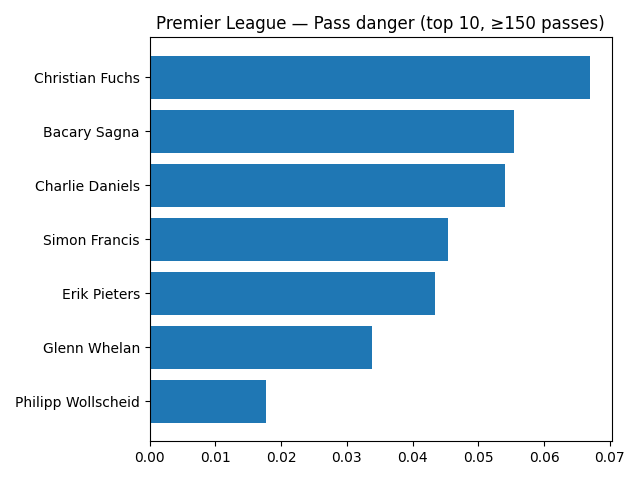

In [45]:
from IPython.display import Image, display
display(Image(filename="outputs\pl_top10_pass_danger_min150.png"))


# AUC visualizations

In [46]:
# [METRICS01] Recompute test predictions for curves (same split as before)
import numpy as np, pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

assert 'df' in globals() and 'feat_cols' in globals(), "[METRICS01] Run your PL training cell first to build df and feat_cols."
X = df[feat_cols].values
y = df["label_shot10"].values

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
pipe_metrics = Pipeline([("scaler", StandardScaler(with_mean=False)),
                         ("clf", LogisticRegression(max_iter=1000, random_state=42))])
pipe_metrics.fit(Xtr, ytr)
probs = pipe_metrics.predict_proba(Xte)[:,1]

auc = roc_auc_score(yte, probs)
ap  = average_precision_score(yte, probs)
print(f"[METRICS01] OK: ROC-AUC={auc:.3f}  AP={ap:.3f}  n_test={len(yte)}  pos_rate={yte.mean():.4f}")

# compute curve points
fpr, tpr, _ = roc_curve(yte, probs)
prec, rec, _ = precision_recall_curve(yte, probs)

OUT = Path("./outputs"); OUT.mkdir(parents=True, exist_ok=True)
np.save(OUT/"roc_points.npy", np.column_stack([fpr, tpr]))
np.save(OUT/"pr_points.npy",  np.column_stack([rec, prec]))
print("[METRICS01] Saved curve points ->", OUT/"roc_points.npy", "and", OUT/"pr_points.npy")


[METRICS01] OK: ROC-AUC=0.791  AP=0.164  n_test=2310  pos_rate=0.0558
[METRICS01] Saved curve points -> outputs\roc_points.npy and outputs\pr_points.npy


In [47]:
# [METRICS02] Plot ROC and PR curves and save PNGs
import matplotlib.pyplot as plt
from pathlib import Path
OUT = Path("./outputs")

# ROC
plt.figure()
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve — Pass→Shot(10s)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUT/"pl_roc_curve.png"); plt.close()
print("[METRICS02] OK:", OUT/"pl_roc_curve.png")

# Precision–Recall
plt.figure()
plt.plot(rec, prec, label=f"AP = {ap:.3f}")
plt.hlines(y=yte.mean(), xmin=0, xmax=1, linestyles="--", label=f"Baseline = {yte.mean():.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall — Pass→Shot(10s)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(OUT/"pl_pr_curve.png"); plt.close()
print("[METRICS02] OK:", OUT/"pl_pr_curve.png")


[METRICS02] OK: outputs\pl_roc_curve.png
[METRICS02] OK: outputs\pl_pr_curve.png


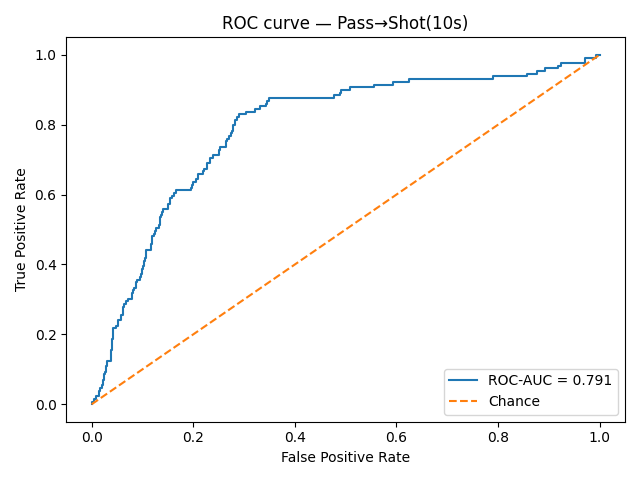

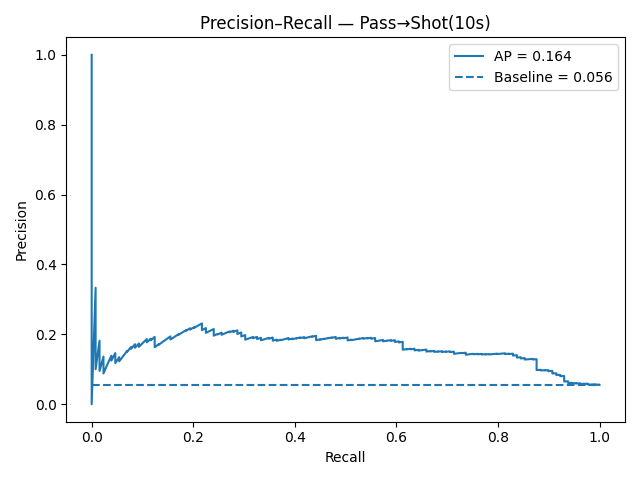

In [48]:
# [METRICS03] Show PNGs inline
from IPython.display import Image, display
display(Image(filename="outputs/pl_roc_curve.png"))
display(Image(filename="outputs/pl_pr_curve.png"))


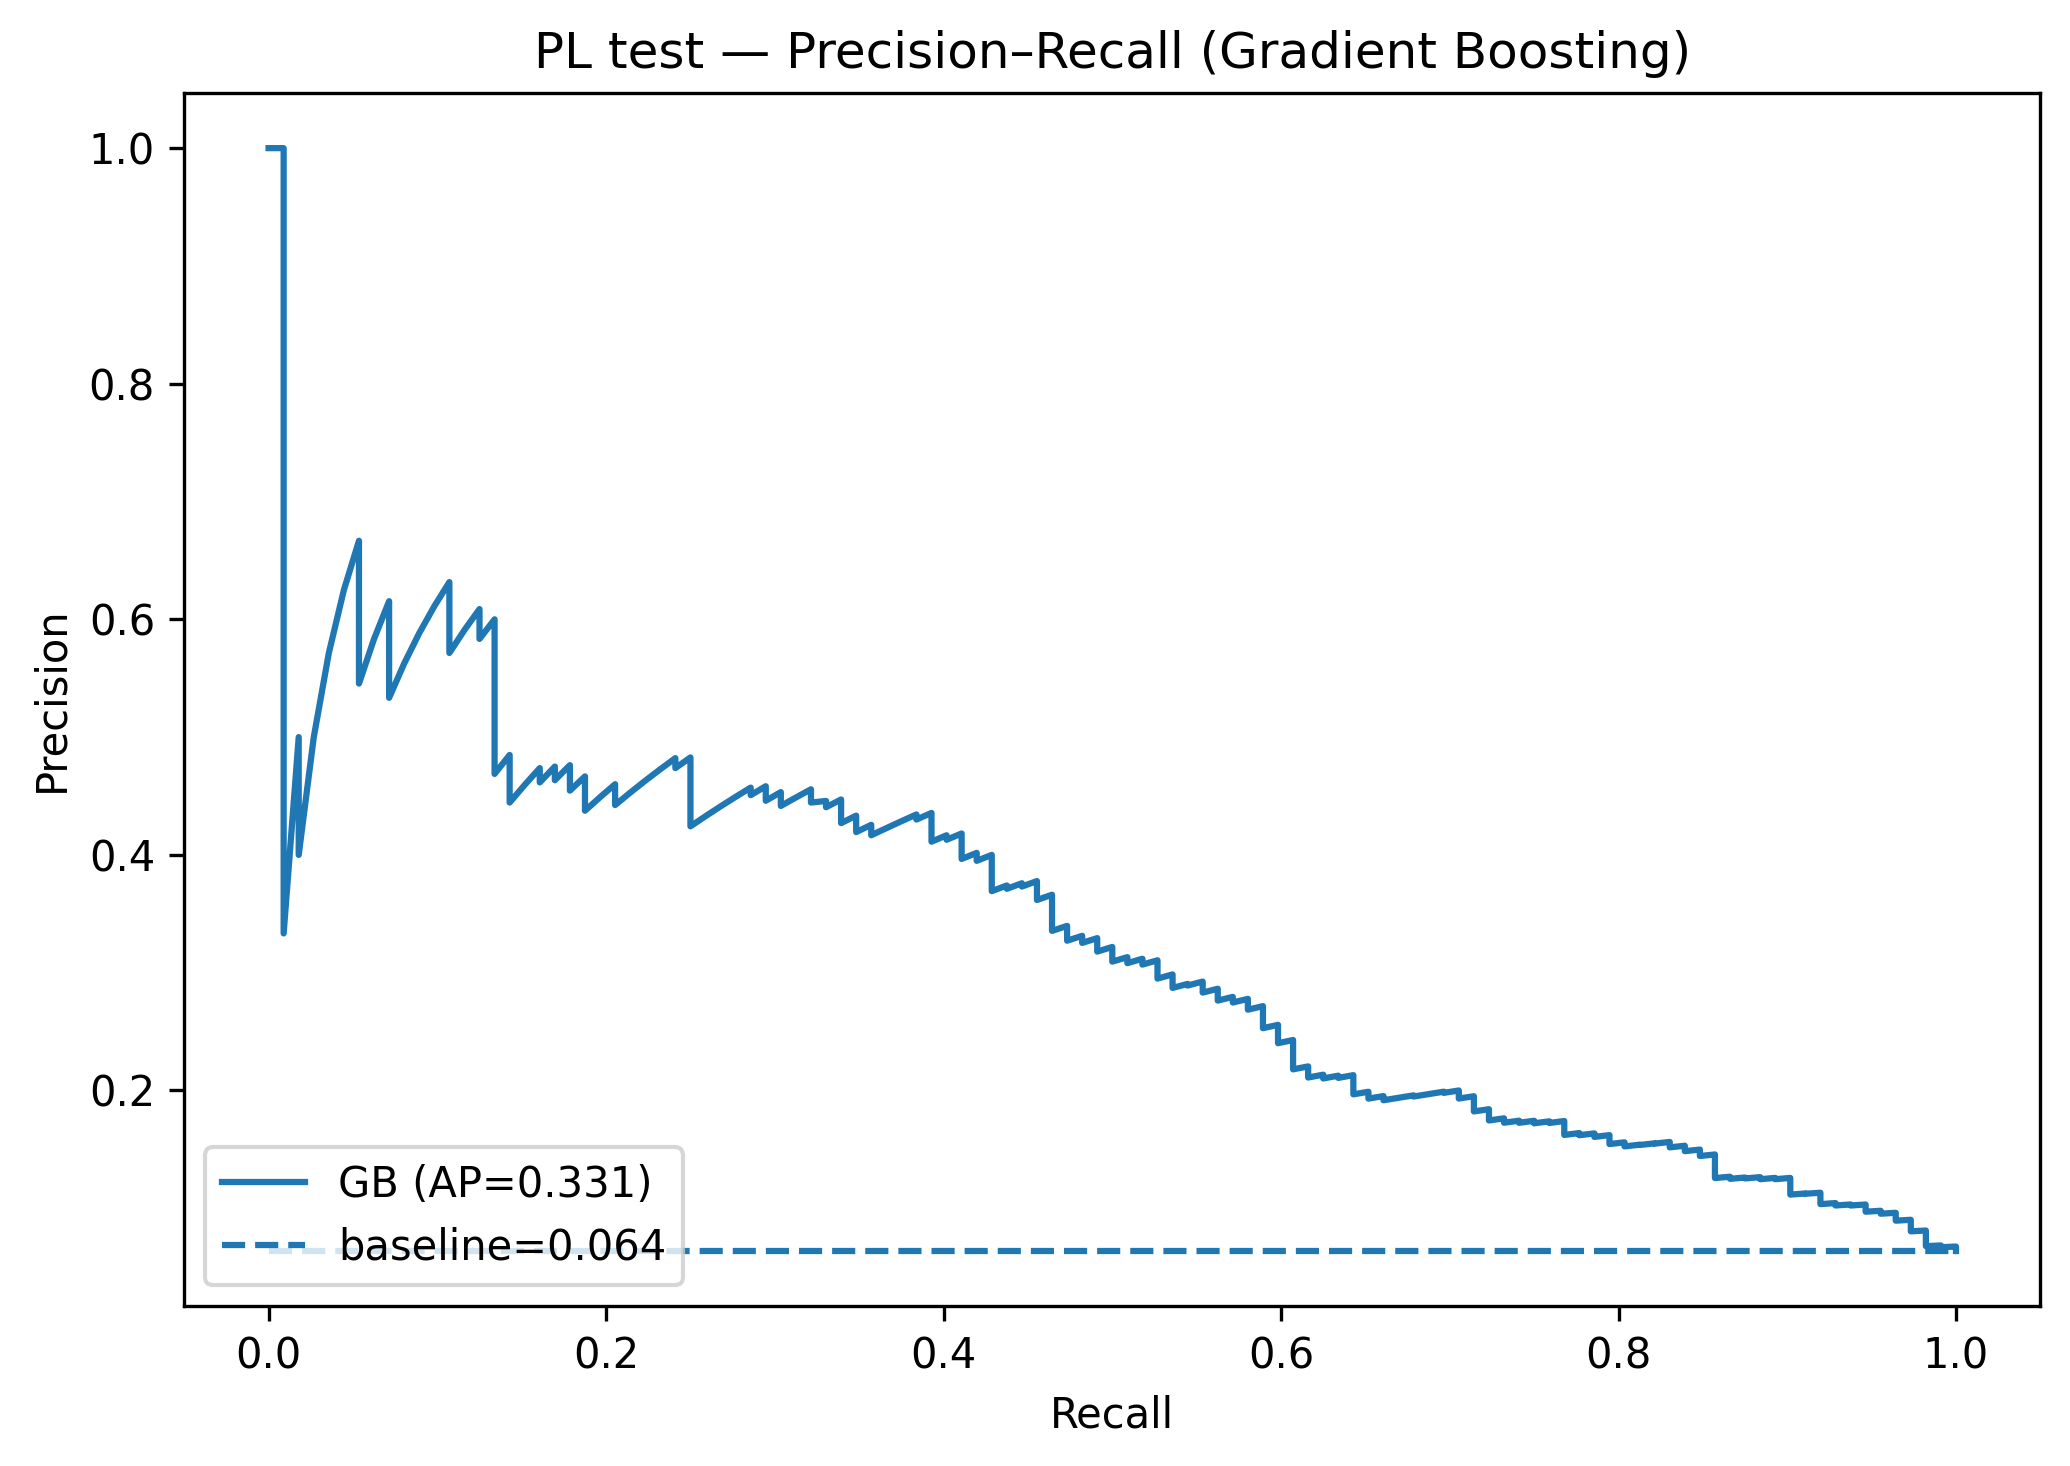

In [49]:
from IPython.display import Image, display
display(Image(filename="outputs/pl_pr_curve_GBoost.png"))


In [50]:
# [METRICS04] Pick operating point by max F1 and report rates
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score

prec, rec, thr = precision_recall_curve(yte, probs)
f1 = 2*prec*rec/(prec+rec+1e-12)
i = f1.argmax()
t = thr[i-1]  # thr is len-1 vs prec/rec
yhat = (probs >= t).astype(int)
print(f"[METRICS04] best_F1={f1[i]:.3f} at threshold={t:.3f}  precision={prec[i]:.3f}  recall={rec[i]:.3f}")
print(f"[METRICS04] positives_in_test={yte.sum()} of {len(yte)} ({yte.mean():.3f})")


[METRICS04] best_F1=0.283 at threshold=0.117  precision=0.189  recall=0.558
[METRICS04] positives_in_test=129 of 2310 (0.056)


In [51]:
# Confusion matrix at t=0.117
import numpy as np
from sklearn.metrics import confusion_matrix
t=0.117
yhat=(probs>=t).astype(int)
tn, fp, fn, tp = confusion_matrix(yte, yhat).ravel()
print(f"TP={tp} FP={fp} FN={fn} TN={tn}")


TP=72 FP=311 FN=57 TN=1870


# finding best player in la liga 

In [52]:
# [T5_LL01] Check model and data dirs
from pathlib import Path
assert 'pipe' in globals() and 'feat_cols' in globals(), "[T5_LL01] Train PL model first (CHK06)."
OTHER_DIR = Path("./statsbomb/events_other")
assert OTHER_DIR.exists(), "[T5_LL01] Missing ./statsbomb/events_other"
files = sorted(OTHER_DIR.glob("*.json"))
print(f"[T5_LL01] OK: other files={len(files)} (need >0).")


[T5_LL01] OK: other files=28 (need >0).


In [53]:
# [T5_LL02] Build features for La Liga and score with PL model
import json, numpy as np, pandas as pd
from pathlib import Path

print("[T5_LL02] START")
rows=[]
for fp in sorted(Path("./statsbomb/events_other").glob("*.json")):
    mid = int(fp.stem)
    for e in json.loads(fp.read_text(encoding="utf-8")):
        d = dict(e); d["match_id"] = d.get("match_id", mid)
        rows.append(d)
ev = pd.json_normalize(rows, sep="_")
print(f"[T5_LL02] events rows={len(ev)}")

# Pass features
def comp(v,i): return v[i] if isinstance(v, list) and len(v)>=2 else np.nan
pa = ev[ev["type_name"]=="Pass"].copy()
pa["x"]=pa["location"].apply(lambda v: comp(v,0))
pa["y"]=pa["location"].apply(lambda v: comp(v,1))
pa["end_x"]=pa["pass_end_location"].apply(lambda v: comp(v,0))
pa["end_y"]=pa["pass_end_location"].apply(lambda v: comp(v,1))
pa["dist"]=np.hypot(pa["end_x"]-pa["x"], pa["end_y"]-pa["y"])
pa["angle"]=np.degrees(np.arctan2(pa["end_y"]-pa["y"], pa["end_x"]-pa["x"]))
pa["forward"]=(pa["end_x"]-pa["x"]>0).astype(int)
pa["height_low"]=(pa["pass_height_name"]=="Low Pass").astype(int)
pa["height_high"]=(pa["pass_height_name"]=="High Pass").astype(int)
pa["body_part_foot"]=(pa["pass_body_part_name"]=="Foot").astype(int)
pa = pa.dropna(subset=feat_cols)
print(f"[T5_LL02] usable passes={len(pa)}")

# Score
pa["prob"] = pipe.predict_proba(pa[feat_cols].values)[:,1]
laliga_rank = (pa.groupby(["player_name","team_name"])["prob"]
               .agg(passes="count", pass_danger="mean")
               .sort_values("pass_danger", ascending=False))
print(f"[T5_LL02] ranked players={len(laliga_rank)}")
print(laliga_rank.head(5))


[T5_LL02] START
[T5_LL02] events rows=102723
[T5_LL02] usable passes=29059
[T5_LL02] ranked players=394
                                                        passes  pass_danger
player_name                     team_name                                  
Jordon Ibe                      Liverpool                    2     0.177589
Florian Thauvin                 Newcastle United             6     0.176785
Federico Nicolás Cartabia       RC Deportivo La Coruña       2     0.154892
Joel Nathaniel Campbell Samuels Arsenal                      5     0.147303
Samuel García Sánchez           Levante UD                   2     0.136500


In [54]:
# [T5_LL03] Save La Liga rankings
from pathlib import Path
OUT = Path("./outputs"); OUT.mkdir(parents=True, exist_ok=True)
laliga_rank.to_csv(OUT/"laliga_player_pass_danger_with_team.csv")
print(f"[T5_LL03] OK: wrote {OUT/'laliga_player_pass_danger_with_team.csv'}")


[T5_LL03] OK: wrote outputs\laliga_player_pass_danger_with_team.csv


In [56]:
# [T5_LL05] Normalize by team average and export shortlist
team_avg = pa.groupby("team_name")["prob"].mean().rename("team_pass_avg").reset_index()
detail = (pa.groupby(["player_name","team_name"])["prob"]
            .agg(passes="count", pass_danger="mean")
            .reset_index())
detail = detail.merge(team_avg, on="team_name", how="left")
detail["player_vs_team"] = detail["pass_danger"] / detail["team_pass_avg"]

shortlist = (detail.query("passes >= @MIN_PASSES")
             .sort_values(["player_vs_team","pass_danger"], ascending=False)
             .head(20))
shortlist.to_csv(OUT/"laliga_shortlist_normalized.csv", index=False)
print(f"[T5_LL05] OK: wrote {OUT/'laliga_shortlist_normalized.csv'}")
print(shortlist.head(10))


[T5_LL05] OK: wrote outputs\laliga_shortlist_normalized.csv
                        player_name    team_name  passes  pass_danger  \
284                 Ousmane Dembélé    Barcelona     255     0.109722   
228  Lionel Andrés Messi Cuccittini    Barcelona    1137     0.105248   
234        Luis Alberto Suárez Díaz    Barcelona     538     0.103350   
299       Philippe Coutinho Correia    Barcelona     479     0.093879   
90           Denis Suárez Fernández    Barcelona     169     0.091064   
25             Andrés Iniesta Luján    Barcelona     799     0.075142   
148              Idrissa Gana Gueye  Aston Villa     166     0.060905   
340          Sergi Roberto Carnicer    Barcelona     968     0.062370   
383             Yann Gérard M''Vila   Sunderland     163     0.056381   
195                Jordi Alba Ramos    Barcelona    1174     0.060987   

     team_pass_avg  player_vs_team  
284       0.058026        1.890900  
228       0.058026        1.813793  
234       0.058026       

In [57]:
# [LLFIX01] Keep only La Liga 2017/18 teams
LA_LIGA_17 = {
 "Alavés","Athletic Club","Atlético Madrid","Barcelona","Celta Vigo","Deportivo La Coruña",
 "Eibar","Espanyol","Getafe","Girona","Las Palmas","Leganés","Levante UD","Málaga",
 "Real Betis","Real Madrid","Real Sociedad","Sevilla","Valencia","Villarreal"
}
pa_ll = pa[pa["team_name"].isin(LA_LIGA_17)].copy()
print("[LLFIX01] OK: passes kept:", len(pa_ll), "teams:", pa_ll['team_name'].nunique())


[LLFIX01] OK: passes kept: 21313 teams: 13


In [58]:
# [LLFIX02] Rank and normalize after filtering
MIN_PASSES = 150
pa_ll["prob"] = pipe.predict_proba(pa_ll[feat_cols].values)[:,1]

laliga_rank = (pa_ll.groupby(["player_name","team_name"])["prob"]
               .agg(passes="count", pass_danger="mean")
               .sort_values("pass_danger", ascending=False))

team_avg = pa_ll.groupby("team_name")["prob"].mean().rename("team_pass_avg").reset_index()
detail = (pa_ll.groupby(["player_name","team_name"])["prob"]
          .agg(passes="count", pass_danger="mean").reset_index()
          .merge(team_avg, on="team_name", how="left"))
detail["player_vs_team"] = detail["pass_danger"] / detail["team_pass_avg"]

shortlist = (detail.query("passes >= @MIN_PASSES")
             .sort_values(["player_vs_team","pass_danger"], ascending=False)
             .head(20))
from pathlib import Path
OUT = Path("./outputs"); OUT.mkdir(parents=True, exist_ok=True)
laliga_rank.to_csv(OUT/"laliga_player_pass_danger_with_team.csv", index=True)
shortlist.to_csv(OUT/"laliga_shortlist_normalized.csv", index=False)
print("[LLFIX02] OK: wrote La Liga CSVs. Top rows:\n", shortlist.head(10))


[LLFIX02] OK: wrote La Liga CSVs. Top rows:
                           player_name  team_name  passes  pass_danger  \
156                   Ousmane Dembélé  Barcelona     255     0.109722   
122    Lionel Andrés Messi Cuccittini  Barcelona    1137     0.105248   
126          Luis Alberto Suárez Díaz  Barcelona     538     0.103350   
166         Philippe Coutinho Correia  Barcelona     479     0.093879   
47             Denis Suárez Fernández  Barcelona     169     0.091064   
14               Andrés Iniesta Luján  Barcelona     799     0.075142   
188            Sergi Roberto Carnicer  Barcelona     968     0.062370   
104                  Jordi Alba Ramos  Barcelona    1174     0.060987   
111  José Paulo Bezzera Maciel Júnior  Barcelona     767     0.057171   
123                       Lucas Digne  Barcelona     251     0.054470   

     team_pass_avg  player_vs_team  
156       0.058026        1.890900  
122       0.058026        1.813793  
126       0.058026        1.781086  
166

In [59]:
# [LLFIX03] Plot La Liga top-10 by pass_danger (≥150)
import matplotlib.pyplot as plt, pandas as pd
ll = laliga_rank.reset_index().query("passes >= @MIN_PASSES").nlargest(10, "pass_danger")
plt.figure(figsize=(8,4.5))
bars = plt.barh(ll["player_name"][::-1], ll["pass_danger"][::-1])
for b,v in zip(bars, ll["pass_danger"][::-1]): plt.text(b.get_width()+0.002, b.get_y()+b.get_height()/2, f"{v:.3f}", va="center")
plt.title(f"La Liga — Pass danger (top 10, ≥{MIN_PASSES} passes)")
plt.xlabel("P(shot within 10s)")
plt.tight_layout(); plt.savefig(OUT/f"laliga_top10_pass_danger_min{MIN_PASSES}.png"); plt.close()
print("[LLFIX03] OK:", OUT/f"laliga_top10_pass_danger_min{MIN_PASSES}.png")


[LLFIX03] OK: outputs\laliga_top10_pass_danger_min150.png


[T5_SHOW_LL] exists=True path=outputs\laliga_top10_pass_danger_min150.png size_bytes=38160


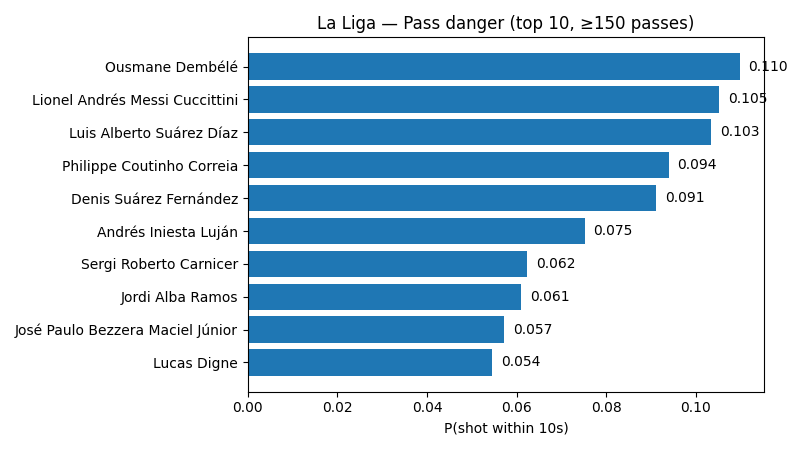

In [60]:
# [T5_SHOW_LL] Display La Liga PNG inline
from IPython.display import Image, display
from pathlib import Path

p = Path("outputs/laliga_top10_pass_danger_min150.png")
print(f"[T5_SHOW_LL] exists={p.exists()} path={p} size_bytes={p.stat().st_size if p.exists() else 'NA'}")
display(Image(filename=str(p)))


# Plotting 

In [1]:
# [PLOT01] Helper to make a top-10 PNG from a ranking CSV
import pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

OUT = Path("./outputs"); OUT.mkdir(parents=True, exist_ok=True)

def make_png(csv_path, title, min_passes, png_name):
    df = pd.read_csv(csv_path).sort_values("pass_danger", ascending=False)
    top = df[df["passes"]>=min_passes].head(10)
    plt.figure(figsize=(8,4.5))
    bars = plt.barh(top["player_name"][::-1], top["pass_danger"][::-1])
    for b,v in zip(bars, top["pass_danger"][::-1]):
        plt.text(b.get_width()+0.002, b.get_y()+b.get_height()/2, f"{v:.3f}", va="center")
    plt.title(title); plt.xlabel("P(shot within 10s)")
    plt.tight_layout(); plt.savefig(OUT/png_name); plt.close()
    print(f"[PLOT01] wrote {OUT/png_name}  rows={len(top)}")


In [2]:
# [PLOT02] Generate all five PNGs (≥150 passes)
MIN_PASSES = 150
make_png("outputs/pl_player_pass_danger.csv",
         f"Premier League 2017/18 — Pass danger (top 10, ≥{MIN_PASSES} passes)",
         MIN_PASSES, f"pl_top10_pass_danger_min{MIN_PASSES}.png")

make_png("outputs/laliga_player_pass_danger_with_team.csv",
         f"La Liga 2017/18 — Pass danger (top 10, ≥{MIN_PASSES} passes)",
         MIN_PASSES, f"laliga_top10_pass_danger_min{MIN_PASSES}.png")

make_png("outputs/bundesliga1516_player_pass_danger_with_team.csv",
         f"Bundesliga 2015/16 — Pass danger (top 10, ≥{MIN_PASSES} passes)",
         MIN_PASSES, f"bundesliga1516_top10_pass_danger_min{MIN_PASSES}.png")

make_png("outputs/seriea1516_player_pass_danger_with_team.csv",
         f"Serie A 2015/16 — Pass danger (top 10, ≥{MIN_PASSES} passes)",
         MIN_PASSES, f"seriea1516_top10_pass_danger_min{MIN_PASSES}.png")

make_png("outputs/ligue1_1516_player_pass_danger_with_team.csv",
         f"Ligue 1 2015/16 — Pass danger (top 10, ≥{MIN_PASSES} passes)",
         MIN_PASSES, f"ligue1_1516_top10_pass_danger_min{MIN_PASSES}.png")


[PLOT01] wrote outputs\pl_top10_pass_danger_min150.png  rows=7
[PLOT01] wrote outputs\laliga_top10_pass_danger_min150.png  rows=10
[PLOT01] wrote outputs\bundesliga1516_top10_pass_danger_min150.png  rows=10
[PLOT01] wrote outputs\seriea1516_top10_pass_danger_min150.png  rows=10
[PLOT01] wrote outputs\ligue1_1516_top10_pass_danger_min150.png  rows=10


[PLOT03] show -> outputs/pl_top10_pass_danger_min150.png


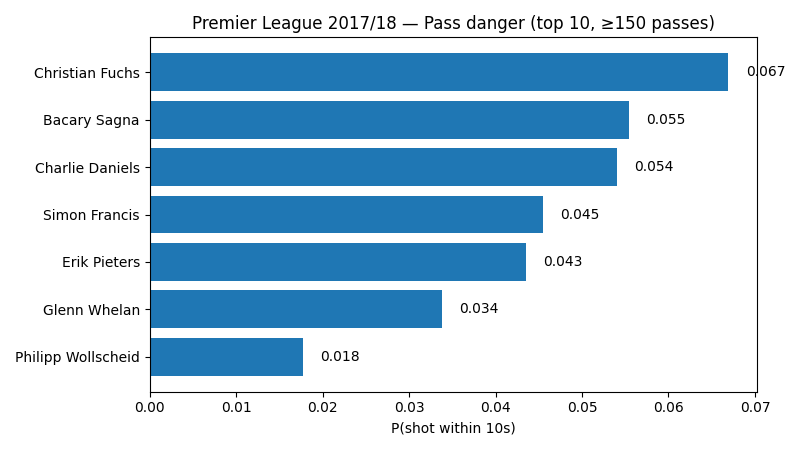

[PLOT03] show -> outputs/laliga_top10_pass_danger_min150.png


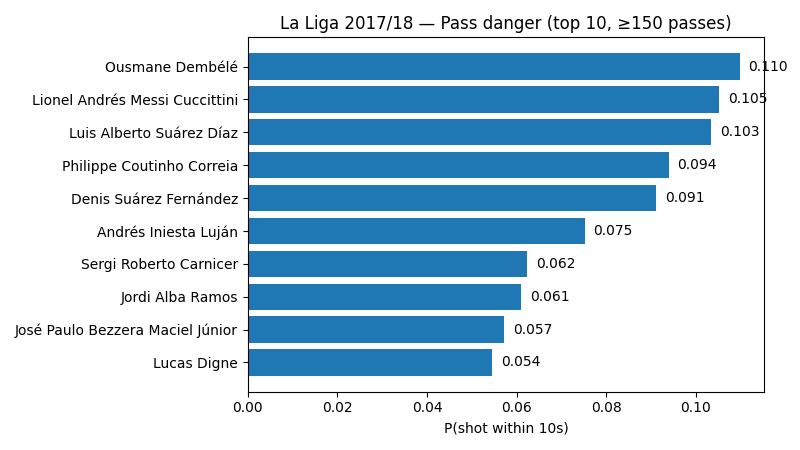

[PLOT03] show -> outputs/bundesliga1516_top10_pass_danger_min150.png


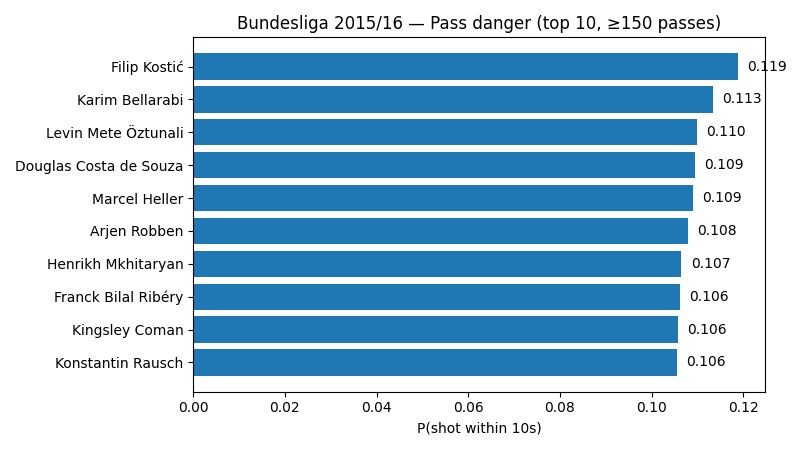

[PLOT03] show -> outputs/seriea1516_top10_pass_danger_min150.png


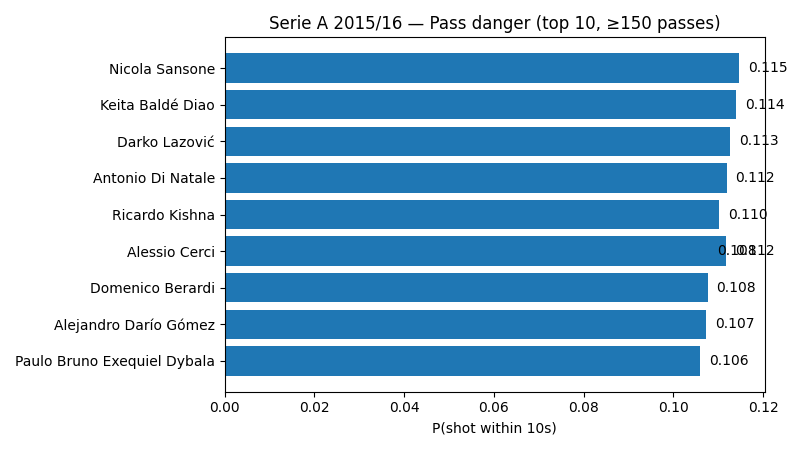

[PLOT03] show -> outputs/ligue1_1516_top10_pass_danger_min150.png


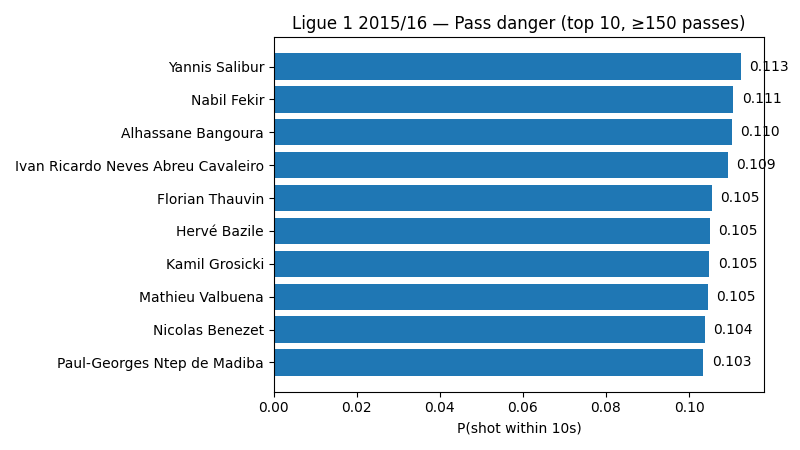

In [3]:
# [PLOT03] Display all PNGs inline
from IPython.display import Image, display
paths = [
    "outputs/pl_top10_pass_danger_min150.png",
    "outputs/laliga_top10_pass_danger_min150.png",
    "outputs/bundesliga1516_top10_pass_danger_min150.png",
    "outputs/seriea1516_top10_pass_danger_min150.png",
    "outputs/ligue1_1516_top10_pass_danger_min150.png",
]
for p in paths:
    print(f"[PLOT03] show -> {p}")
    display(Image(filename=p))


# PNG

In [4]:
# [PRES01] PL top-10 chart from outputs/pl_player_pass_danger.csv
import pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

OUT = Path("./outputs"); OUT.mkdir(exist_ok=True, parents=True)
pl = pd.read_csv(OUT/"pl_player_pass_danger.csv")
pl = pl.sort_values("pass_danger", ascending=False)
pl_top = pl[pl["passes"]>=200].head(10)

plt.figure()
plt.barh(pl_top["player_name"][::-1], pl_top["pass_danger"][::-1])
plt.title("Premier League — Pass danger (top 10, ≥200 passes)")
plt.tight_layout()
plt.savefig(OUT/"pl_top10_pass_danger.png"); plt.close()
print("[PRES01] OK:", OUT/"pl_top10_pass_danger.png")


[PRES01] OK: outputs\pl_top10_pass_danger.png


In [5]:
# [PRES02A] Build La Liga ranking -> outputs/laliga_player_pass_danger.csv
from pathlib import Path
import numpy as np, pandas as pd, json

assert 'pipe' in globals() and 'feat_cols' in globals(), "[PRES02A] Train PL model first (CHK06)."

OTHER_EVENTS_DIR = Path("./statsbomb/events_other")
OUT = Path("./outputs"); OUT.mkdir(parents=True, exist_ok=True)

files_o = sorted(OTHER_EVENTS_DIR.glob("*.json"))
assert files_o, "[PRES02A] No files in ./statsbomb/events_other. Run NB19."

# load events and inject match_id
rows = []
for fp in files_o:
    mid = int(fp.stem)
    for e in json.loads(fp.read_text(encoding="utf-8")):
        d = dict(e); d["match_id"] = d.get("match_id", mid)
        rows.append(d)

# FIXED QUOTE HERE ↓
ev = pd.json_normalize(rows, sep="_")

# passes + features
def comp(v,i): return v[i] if isinstance(v, list) and len(v)>=2 else np.nan
pass_o = ev[ev["type_name"]=="Pass"].copy()
pass_o["x"] = pass_o["location"].apply(lambda v: comp(v,0))
pass_o["y"] = pass_o["location"].apply(lambda v: comp(v,1))
pass_o["end_x"] = pass_o["pass_end_location"].apply(lambda v: comp(v,0))
pass_o["end_y"] = pass_o["pass_end_location"].apply(lambda v: comp(v,1))
pass_o["dist"] = np.hypot(pass_o["end_x"]-pass_o["x"], pass_o["end_y"]-pass_o["y"])
pass_o["angle"] = np.degrees(np.arctan2(pass_o["end_y"]-pass_o["y"], pass_o["end_x"]-pass_o["x"]))
pass_o["forward"] = (pass_o["end_x"] - pass_o["x"] > 0).astype(int)
pass_o["height_low"] = (pass_o["pass_height_name"]=="Low Pass").astype(int)
pass_o["height_high"] = (pass_o["pass_height_name"]=="High Pass").astype(int)
pass_o["body_part_foot"] = (pass_o["pass_body_part_name"]=="Foot").astype(int)

pass_o = pass_o.dropna(subset=feat_cols)
pass_o["prob"] = pipe.predict_proba(pass_o[feat_cols].values)[:,1]
laliga_rank = (pass_o.groupby("player_name")["prob"]
               .agg(passes="count", pass_danger="mean")
               .sort_values("pass_danger", ascending=False))
laliga_rank.to_csv(OUT/"laliga_player_pass_danger.csv")
print("[PRES02A] OK:", OUT/"laliga_player_pass_danger.csv", "players=", len(laliga_rank))


AssertionError: [PRES02A] Train PL model first (CHK06).

In [ ]:
# [PRES02B] Create outputs/laliga_top10_pass_danger.png
import pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

OUT = Path("./outputs"); OUT.mkdir(parents=True, exist_ok=True)
ll = pd.read_csv(OUT/"laliga_player_pass_danger.csv").sort_values("pass_danger", ascending=False)
ll_top = ll[ll["passes"]>=200].head(10)

plt.figure()
plt.barh(ll_top["player_name"][::-1], ll_top["pass_danger"][::-1])
plt.title("La Liga — Pass danger (top 10, ≥200 passes)")
plt.tight_layout()
plt.savefig(OUT/"laliga_top10_pass_danger.png"); plt.close()
print("[PRES02B] OK:", OUT/"laliga_top10_pass_danger.png")


In [ ]:
# [PRES03] Display saved charts inline
from IPython.display import display, Image
from pathlib import Path

OUT = Path("./outputs")
files = [OUT/"pl_top10_pass_danger.png", OUT/"laliga_top10_pass_danger.png"]

for f in files:
    if f.exists():
        print(f"[PRES03] OK:", f)
        display(Image(filename=str(f)))
    else:
        print(f"[PRES03] MISSING:", f)


# check if everything is ok 

In [ ]:
# [CHK01] Confirm working dir and data folders
from pathlib import Path
DATA_DIR = Path("./statsbomb")
EVENTS_PL_DIR = DATA_DIR / "events"            # PL cache from earlier steps
EVENTS_OTHER_DIR = DATA_DIR / "events_other"   # non-PL cache (optional)
print(f"[CHK01] OK: cwd={Path().resolve()}")
print(f"[CHK01] OK: DATA_DIR={DATA_DIR} exists={DATA_DIR.exists()}")
print(f"[CHK01] OK: PL events dir={EVENTS_PL_DIR} exists={EVENTS_PL_DIR.exists()}")
print(f"[CHK01] OK: Other events dir={EVENTS_OTHER_DIR} exists={EVENTS_OTHER_DIR.exists()}")


In [ ]:
# [CHK02] Count PL event files
from pathlib import Path
pl_files = sorted(EVENTS_PL_DIR.glob("*.json")) if EVENTS_PL_DIR.exists() else []
print(f"[CHK02] OK: PL event files={len(pl_files)} sample={[p.name for p in pl_files[:5]]}")
if not pl_files:
    print("[CHK02] ERROR: No PL events cached. Re-run your PL download cell (NB07).")


In [ ]:
# [CHK03] Inspect first PL event file: length and keys
import json
if pl_files:
    sample = json.loads(pl_files[0].read_text(encoding="utf-8"))
    kind = "list" if isinstance(sample, list) else type(sample).__name__
    first_keys = list(sample[0].keys())[:15] if isinstance(sample, list) and sample else []
    print(f"[CHK03] OK: file={pl_files[0].name} type={kind} events_in_file={len(sample) if isinstance(sample,list) else 'n/a'}")
    print(f"[CHK03] OK: first event keys={first_keys}")
    if isinstance(sample, list) and sample and ("type" in sample[0] or "type_name" in sample[0]):
        print("[CHK03] OK: Looks like StatsBomb event dicts.")
    else:
        print("[CHK03] WARN: Unexpected event shape. Proceed but expect key adjustments.")
else:
    print("[CHK03] SKIP: No files.")


In [ ]:
# [CHK04] Build a proper bundle: {"matches":[...], "events_per_match":[...]}
import json
from pathlib import Path

def build_pl_bundle(events_dir: Path, out_path: Path) -> bool:
    files = sorted(events_dir.glob("*.json"))
    if not files:
        print("[CHK04] ERROR: No PL event files to bundle.")
        return False
    matches, events_per_match = [], []
    for fp in files:
        try:
            mid = int(fp.stem)
        except ValueError:
            print(f"[CHK04] WARN: non-numeric filename {fp.name}; skipping")
            continue
        evs = json.loads(fp.read_text(encoding="utf-8"))
        if not isinstance(evs, list):
            print(f"[CHK04] WARN: {fp.name} is not a list; skipping")
            continue
        matches.append(mid)
        events_per_match.append(evs)
    if not matches:
        print("[CHK04] ERROR: No valid PL event lists gathered.")
        return False
    bundle = {
        "competition_name": "Premier League",
        "season_name": "2017/2018",
        "competition_id": None,
        "season_id": None,
        "matches": matches,
        "events_per_match": events_per_match,
    }
    out_path.write_text(json.dumps(bundle, ensure_ascii=False), encoding="utf-8")
    print(f"[CHK04] OK: wrote {out_path} matches={len(matches)}")
    return True

ok = build_pl_bundle(EVENTS_PL_DIR, Path("events_England.json"))


In [ ]:
# [CHK05] Load first few events from the bundle and check for type_name
import json, pandas as pd
from pathlib import Path

p = Path("events_England.json")
if not p.exists():
    print("[CHK05] ERROR: events_England.json missing. Run CHK04 first.")
else:
    obj = json.loads(p.read_text(encoding="utf-8"))
    rows = []
    if isinstance(obj, dict) and "events_per_match" in obj:
        mlist = obj.get("matches", [])
        for i, evs in enumerate(obj["events_per_match"][:3]):
            mid = mlist[i] if i < len(mlist) else i
            for e in evs[:15]:
                d = dict(e); d["match_id"] = d.get("match_id", mid)
                rows.append(d)
    else:
        print("[CHK05] ERROR: Unexpected JSON shape. Rebuild with CHK04.")
    df = pd.json_normalize(rows, sep="_") if rows else pd.DataFrame()
    print(f"[CHK05] OK: preview_rows={len(df)} has_type_name={'type_name' in df.columns}")
    if "type_name" not in df.columns:
        print("[CHK05] ERROR: No 'type_name' found. Your event files may be empty or malformed.")


In [ ]:
# [CHK06F] Score all passes, rank players, write outputs
from pathlib import Path
import pandas as pd

assert 'pipe' in globals() and 'feat_cols' in globals() and 'df' in globals(), "[CHK06F] ERROR: run CHK06 first."

# 1) Score
df = df.copy()
df["prob"] = pipe.predict_proba(df[feat_cols].values)[:,1]
print(f"[CHK06F] OK: scored rows={len(df)} prob_mean={df['prob'].mean():.4f}")

# 2) Rank
player_rank = (df.groupby("player_name")["prob"]
               .agg(passes="count", pass_danger="mean")
               .sort_values("pass_danger", ascending=False))
print(f"[CHK06F] OK: ranked players={len(player_rank)}")
print("[CHK06F] PREVIEW (top 10):\n", player_rank.head(10))

# 3) Save
OUT = Path("./outputs"); OUT.mkdir(parents=True, exist_ok=True)
player_rank.to_csv(OUT/"pl_player_pass_danger.csv")
df.sample(min(1000, len(df)), random_state=42)[
    [c for c in ["player_name","team_name","t","prob","x","y","end_x","end_y","dist","angle","forward"] if c in df.columns]
].to_csv(OUT/"pl_scored_passes_sample.csv", index=False)
print(f"[CHK06F] OK: wrote {OUT/'pl_player_pass_danger.csv'} and {OUT/'pl_scored_passes_sample.csv'}")


In [ ]:
# [CHK07] Filter by volume and show top 15
MIN_PASSES = 200  # drop to 150 if empty
pl_top = (player_rank.reset_index()
          .query("passes >= @MIN_PASSES")
          .nlargest(15, "pass_danger"))
print(f"[CHK07] OK: players >= {MIN_PASSES} passes = {len(pl_top)}")
print(pl_top)


In [ ]:
# [CHK08] Save filtered table for slides
from pathlib import Path
OUT = Path("./outputs"); OUT.mkdir(parents=True, exist_ok=True)
pl_top.to_csv(OUT / f"pl_player_pass_danger_top_{MIN_PASSES}.csv", index=False)
print(f"[CHK08] OK: wrote {OUT / f'pl_player_pass_danger_top_{MIN_PASSES}.csv'}")


In [ ]:
# [CHK09] Normalize by team mean to reduce big-team bias
import pandas as pd
assert "team_name" in df.columns, "[CHK09] ERROR: team_name missing in df."

team_avg = df.groupby("team_name")["prob"].mean().rename("team_pass_avg")
pl_detail = (df.groupby(["player_name","team_name"])["prob"]
               .agg(passes="count", pass_danger="mean")
               .reset_index()
               .merge(team_avg, on="team_name", how="left"))
pl_detail["player_vs_team"] = pl_detail["pass_danger"] / pl_detail["team_pass_avg"]

MIN_PASSES_NORM = 200
pl_norm = (pl_detail.query("passes >= @MIN_PASSES_NORM")
           .sort_values(["player_vs_team","pass_danger"], ascending=False)
           .head(15))
print(f"[CHK09] OK: normalized shortlist rows={len(pl_norm)}")
print(pl_norm.head(15))


In [ ]:
# [CHK10] Top teams by pass rows to spot league mix
team_counts = df.groupby("team_name")["prob"].count().sort_values(ascending=False).head(20)
print("[CHK10] OK: top teams by pass rows:\n", team_counts)


In [ ]:
# [CHK11] Freeze top-15 with >=200 passes for your deck
MIN_PASSES = 200
pl_top = (player_rank.reset_index()
          .query("passes >= @MIN_PASSES")
          .nlargest(15, "pass_danger"))
pl_top.to_csv("outputs/pl_top15_min200.csv", index=False)
print("[CHK11] OK: wrote outputs/pl_top15_min200.csv")
print(pl_top)


In [ ]:
# [CHK12] Build a paste-ready bullet list for Slide 2
lines = ["Shortlist (>=200 passes):"]
for _, r in pl_top.iterrows():
    lines.append(f"- {r['player_name']}: danger={r['pass_danger']:.3f} (passes={int(r['passes'])})")
txt = "\n".join(lines)
print("[CHK12] OK:\n" + txt)


# Trying other ML techniques 

In [ ]:
# [ALT01] Prep same split as before
assert 'df' in globals() and 'feat_cols' in globals(), "[ALT01] Build df + feat_cols first."
from sklearn.model_selection import train_test_split
X = df[feat_cols].values
y = df["label_shot10"].values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"[ALT01] n_train={len(ytr)} n_test={len(yte)} pos_rate_test={yte.mean():.3f}")


In [ ]:
# [ALT02] Elastic-net logistic
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
pipe_en = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(
        penalty="elasticnet", solver="saga", l1_ratio=0.3,
        class_weight="balanced", max_iter=3000, random_state=42))
])
pipe_en.fit(Xtr, ytr)
p_en = pipe_en.predict_proba(Xte)[:,1]
print(f"[ALT02] EN-LR  AUC={roc_auc_score(yte,p_en):.3f}  AP={average_precision_score(yte,p_en):.3f}")


In [ ]:
# [ALT03] Random Forest + calibration
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
rf = RandomForestClassifier(
    n_estimators=400, max_depth=None, min_samples_leaf=2,
    class_weight="balanced_subsample", n_jobs=-1, random_state=42)
cal_rf = CalibratedClassifierCV(rf, method="isotonic", cv=3)
cal_rf.fit(Xtr, ytr)
p_rf = cal_rf.predict_proba(Xte)[:,1]
print(f"[ALT03] RF+Cal AUC={roc_auc_score(yte,p_rf):.3f}  AP={average_precision_score(yte,p_rf):.3f}")


In [ ]:
# [ALT04] Gradient Boosting (sklearn, no extra deps)
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=3, random_state=42)
gb.fit(Xtr, ytr)
p_gb = gb.predict_proba(Xte)[:,1]
print(f"[ALT04] GBoost AUC={roc_auc_score(yte,p_gb):.3f}  AP={average_precision_score(yte,p_gb):.3f}")


In [ ]:
# [ALT05] Pick best by AP, re-rank PL players, save PNG
import numpy as np, pandas as pd, matplotlib.pyplot as plt
cands = [("EN-LR", pipe_en, p_en), ("RF+Cal", cal_rf, p_rf), ("GBoost", gb, p_gb)]
metrics = [(name,
            roc_auc_score(yte, probs),
            average_precision_score(yte, probs)) for name,_,probs in cands]
tbl = pd.DataFrame(metrics, columns=["model","ROC_AUC","AP"]).sort_values("AP", ascending=False)
print("[ALT05] Model comparison by AP:\n", tbl)

best_name, best_model, _ = max(cands, key=lambda t: average_precision_score(yte, t[2]))
print(f"[ALT05] Selected model: {best_name}")

# score all PL passes in df and aggregate by player
df["prob_best"] = best_model.predict_proba(df[feat_cols].values)[:,1]
rank = (df.groupby("player_name")["prob_best"]
          .agg(passes="count", pass_danger="mean")
          .sort_values("pass_danger", ascending=False)
          .reset_index())
from pathlib import Path
OUT = Path("./outputs"); OUT.mkdir(parents=True, exist_ok=True)
rank.to_csv(OUT/f"pl_player_pass_danger_{best_name}.csv", index=False)

MIN_PASSES=150
top = rank[rank["passes"]>=MIN_PASSES].head(10)
plt.figure(figsize=(8,4.5))
bars = plt.barh(top["player_name"][::-1], top["pass_danger"][::-1])
for b,v in zip(bars, top["pass_danger"][::-1]):
    plt.text(b.get_width()+0.002, b.get_y()+b.get_height()/2, f"{v:.3f}", va="center")
plt.title(f"Premier League — Pass danger by {best_name} (top 10, ≥{MIN_PASSES} passes)")
plt.xlabel("P(shot within 10s)"); plt.tight_layout()
png = OUT/f"pl_top10_pass_danger_{best_name}_min{MIN_PASSES}.png"
plt.savefig(png); plt.close()
print(f"[ALT05] wrote {png}")


In [ ]:
# [ALT06] Show the chosen PL PNG
from IPython.display import Image, display
display(Image(filename=png))


# La liga with Gboost

In [ ]:
# [GLL01] Require 'gb' (from ALT04), 'feat_cols', and La Liga pass table 'pa_ll'
assert 'gb' in globals() and 'feat_cols' in globals(), "[GLL01] run ALT04 first."
assert 'pa_ll' in globals(), "[GLL01] build La Liga passes (LLFIX01→02) first."

from pathlib import Path
import pandas as pd, matplotlib.pyplot as plt

pa_ll = pa_ll.copy()
pa_ll["prob_gb"] = gb.predict_proba(pa_ll[feat_cols].values)[:,1]

laliga_gb = (pa_ll.groupby(["player_name","team_name"])["prob_gb"]
             .agg(passes="count", pass_danger="mean")
             .sort_values("pass_danger", ascending=False)
             .reset_index())

OUT = Path("./outputs"); OUT.mkdir(parents=True, exist_ok=True)
laliga_gb.to_csv(OUT/"laliga_player_pass_danger_GBoost.csv", index=False)

MIN_PASSES=150
top = laliga_gb[laliga_gb["passes"]>=MIN_PASSES].head(10)
plt.figure(figsize=(8,4.5))
bars = plt.barh(top["player_name"][::-1], top["pass_danger"][::-1])
for b,v in zip(bars, top["pass_danger"][::-1]): plt.text(b.get_width()+0.002, b.get_y()+b.get_height()/2, f"{v:.3f}", va="center")
plt.title(f"La Liga — Pass danger by GBoost (top 10, ≥{MIN_PASSES} passes)")
plt.xlabel("P(shot within 10s)")
plt.tight_layout(); png_ll = OUT/f"laliga_top10_pass_danger_GBoost_min{MIN_PASSES}.png"
plt.savefig(png_ll); plt.close()
print("[GLL01] wrote", png_ll)


In [ ]:
# [GGEN] Rescore a league from its event folder path
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

def rescore_events_dir(events_dir: str, png_prefix: str, min_passes=150):
    rows=[]
    for fp in sorted(Path(events_dir).glob("*.json")):
        evs = json.loads(Path(fp).read_text(encoding="utf-8"))
        for e in evs:
            d=dict(e); d["match_id"]=d.get("match_id", int(Path(fp).stem)); rows.append(d)
    ev = pd.json_normalize(rows, sep="_")
    def comp(v,i): return v[i] if isinstance(v,list) and len(v)>=2 else np.nan
    pa = ev[ev["type_name"]=="Pass"].copy()
    pa["x"]=pa["location"].apply(lambda v: comp(v,0)); pa["y"]=pa["location"].apply(lambda v: comp(v,1))
    pa["end_x"]=pa["pass_end_location"].apply(lambda v: comp(v,0)); pa["end_y"]=pa["pass_end_location"].apply(lambda v: comp(v,1))
    pa["dist"]=np.hypot(pa["end_x"]-pa["x"], pa["end_y"]-pa["y"])
    pa["angle"]=np.degrees(np.arctan2(pa["end_y"]-pa["y"], pa["end_x"]-pa["x"]))
    pa["forward"]=(pa["end_x"]-pa["x"]>0).astype(int)
    pa["height_low"]=(pa["pass_height_name"]=="Low Pass").astype(int)
    pa["height_high"]=(pa["pass_height_name"]=="High Pass").astype(int)
    pa["body_part_foot"]=(pa["pass_body_part_name"]=="Foot").astype(int)
    pa = pa.dropna(subset=feat_cols)

    pa["prob_gb"]=gb.predict_proba(pa[feat_cols].values)[:,1]
    rank=(pa.groupby(["player_name","team_name"])["prob_gb"]
            .agg(passes="count", pass_danger="mean")
            .sort_values("pass_danger", ascending=False)
            .reset_index())
    OUT=Path("./outputs"); OUT.mkdir(parents=True, exist_ok=True)
    rank.to_csv(OUT/f"{png_prefix}_player_pass_danger_GBoost.csv", index=False)

    top=rank[rank["passes"]>=min_passes].head(10)
    plt.figure(figsize=(8,4.5))
    bars=plt.barh(top["player_name"][::-1], top["pass_danger"][::-1])
    for b,v in zip(bars, top["pass_danger"][::-1]): plt.text(b.get_width()+0.002, b.get_y()+b.get_height()/2, f"{v:.3f}", va="center")
    plt.title(f"{png_prefix.replace('_',' ').title()} — Pass danger by GBoost (top 10, ≥{min_passes} passes)")
    plt.xlabel("P(shot within 10s)"); plt.tight_layout()
    png=OUT/f"{png_prefix}_top10_pass_danger_GBoost_min{min_passes}.png"
    plt.savefig(png); plt.close()
    print("[GGEN] wrote", png)
    return png

# Examples (adjust paths if needed):
# rescore_events_dir("./statsbomb/events_bundesliga_1516", "bundesliga_1516")
# rescore_events_dir("./statsbomb/events_seriea_1516", "serie_a_1516")
# rescore_events_dir("./statsbomb/events_ligue1_1516", "ligue1_1516")


In [ ]:
# [SHOW_GB_PL] Display PL GBoost top-10 PNG
from IPython.display import Image, display
from pathlib import Path
p = Path("outputs/pl_top10_pass_danger_GBoost_min150.png")
print(f"[SHOW_GB_PL] exists={p.exists()} size={p.stat().st_size if p.exists() else 'NA'}")
display(Image(filename=str(p)))


In [ ]:
# [SHOW_GB_LL] Display La Liga GBoost top-10 PNG
from IPython.display import Image, display
from pathlib import Path
p = Path("outputs/laliga_top10_pass_danger_GBoost_min150.png")
print(f"[SHOW_GB_LL] exists={p.exists()} size={p.stat().st_size if p.exists() else 'NA'}")
display(Image(filename=str(p)))


In [ ]:
# quick file sanity
from pathlib import Path; out=Path("outputs")
print(sorted(p.name for p in out.glob("pl_*GBoost*.png")))
print(sorted(p.name for p in out.glob("laliga_*GBoost*.png")))
print((out/"pl_pr_curve.png").exists())


# Visualization for powerpoint 

In [ ]:
# [SL1_PR] Display Precision–Recall curve PNG for Slide 1
from IPython.display import Image, display
from pathlib import Path

p = Path("outputs/pl_pr_curve.png")
print(f"[SL1_PR] exists={p.exists()} size={p.stat().st_size if p.exists() else 'NA'} path={p}")
display(Image(filename=str(p)))


In [ ]:
# [SL1_PR_GB] Precision–Recall for GBoost and save PNG
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

assert 'p_gb' in globals() and 'yte' in globals(), "[SL1_PR_GB] Run ALT04 first to get p_gb,yte."

ap = average_precision_score(yte, p_gb)
rec, prec, _ = precision_recall_curve(yte, p_gb)

OUT = Path("./outputs"); OUT.mkdir(exist_ok=True, parents=True)
plt.figure()
plt.plot(rec, prec, label=f"AP = {ap:.3f}")
plt.hlines(y=yte.mean(), xmin=0, xmax=1, linestyles="--", label=f"Baseline = {yte.mean():.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall — Pass→Shot(10s) [GBoost]")
plt.legend(loc="upper right")
plt.tight_layout(); plt.savefig(OUT/"pl_pr_curve_GBoost.png"); plt.close()
print("[SL1_PR_GB] OK:", OUT/"pl_pr_curve_GBoost.png")


In [ ]:
# [SL1_SHOW_GB] Display the GBoost PR curve
from IPython.display import Image, display
display(Image(filename="outputs/pl_pr_curve_GBoost.png"))


In [ ]:
# [SL2_SHOW] Show PL + La Liga PNGs side-by-side
from IPython.display import display, HTML
from pathlib import Path

pl = Path("outputs/pl_top10_pass_danger_GBoost_min150.png")
ll = Path("outputs/laliga_top10_pass_danger_GBoost_min150.png")
print(f"[SL2_SHOW] PL exists={pl.exists()} size={pl.stat().st_size if pl.exists() else 'NA'}")
print(f"[SL2_SHOW] LL exists={ll.exists()} size={ll.stat().st_size if ll.exists() else 'NA'}")

html = f"""
<div style="display:flex; gap:16px;">
  <div style="flex:1; text-align:center;">
    <img src="{pl.as_posix()}" style="width:100%; max-width:600px;"><br>
    <small>Premier League — Pass danger (≥150)</small>
  </div>
  <div style="flex:1; text-align:center;">
    <img src="{ll.as_posix()}" style="width:100%; max-width:600px;"><br>
    <small>La Liga — Pass danger (≥150)</small>
  </div>
</div>
"""
display(HTML(html))


# test 

In [ ]:
# train_pl_pass_danger.py
# Deterministic PL pass_danger model. Runs offline beside events_England.json.
# Outputs (in ./outputs):
#   - pl_pr_curve_GBoost.png
#   - pl_top10_pass_danger_GBoost_min150.png
#   - pl_player_pass_danger_GBoost.csv

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.ensemble import GradientBoostingClassifier

# ---------- constants (deterministic) ----------
OUTDIR = Path("outputs"); OUTDIR.mkdir(exist_ok=True)
EVENTS_FILE = "events_England.json"
MIN_PASSES = 150
RNG = 42
np.random.seed(RNG)

# ---------- load events ----------
def load_events(path=EVENTS_FILE) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8") as f:
        txt = f.read().lstrip("\ufeff")

    try:
        obj = json.loads(txt)
    except json.JSONDecodeError:
        # NDJSON fallback
        obj = [json.loads(line) for line in txt.splitlines() if line.strip()]

    rows = []
    if isinstance(obj, dict) and "events_per_match" in obj and "matches" in obj:
        # bundled format: {"matches":[...], "events_per_match":[ [ev,...], ... ]}
        for i, evs in enumerate(obj["events_per_match"]):
            mid = obj["matches"][i]
            for e in evs:
                d = dict(e)
                d["match_id"] = d.get("match_id", mid)
                rows.append(d)
    elif isinstance(obj, list):
        # flat list of events
        for e in obj:
            d = dict(e)
            d["match_id"] = d.get("match_id", d.get("game_id"))
            rows.append(d)
    else:
        raise ValueError("Unsupported JSON structure in events_England.json")

    ev = pd.json_normalize(rows, sep="_")

    # optional PL-only filter (no-op if columns absent)
    if "competition_name" in ev:
        ev = ev[ev["competition_name"].eq("Premier League")]
    if "season_name" in ev:
        ev = ev[ev["season_name"].astype(str).str.contains("2017/2018", na=False)]

    # ensure key columns
    for c in ["type_name","location","minute","second","possession",
              "team_id","team_name","player_name","possession_team_id"]:
        if c not in ev:
            ev[c] = np.nan

    # timestamp in seconds
    ev["minute"] = pd.to_numeric(ev["minute"], errors="coerce").fillna(0).astype(int)
    ev["second"] = pd.to_numeric(ev["second"], errors="coerce").fillna(0.0)
    ev["time_s"] = ev["minute"] * 60 + ev["second"]

    # fallback for possession_team_id
    ev["possession_team_id"] = ev["possession_team_id"].fillna(ev["team_id"])

    return ev

# ---------- features on completed passes ----------
def create_pass_features(events: pd.DataFrame) -> pd.DataFrame:
    if "pass_outcome_name" not in events:
        events["pass_outcome_name"] = np.nan

    passes = events[(events["type_name"]=="Pass") & (events["pass_outcome_name"].isna())].copy()

    def comp(v, i):
        return v[i] if isinstance(v, list) and len(v) >= 2 else np.nan

    passes["x"] = passes["location"].apply(lambda v: comp(v, 0))
    passes["y"] = passes["location"].apply(lambda v: comp(v, 1))
    if "pass_end_location" not in passes:
        passes["pass_end_location"] = np.nan
    passes["end_x"] = passes["pass_end_location"].apply(lambda v: comp(v, 0))
    passes["end_y"] = passes["pass_end_location"].apply(lambda v: comp(v, 1))

    passes = passes.dropna(subset=["x","y","end_x","end_y"]).copy()

    dx = passes["end_x"] - passes["x"]
    dy = passes["end_y"] - passes["y"]
    passes["dist"]    = np.hypot(dx, dy)
    passes["angle"]   = np.degrees(np.arctan2(dy, dx))
    passes["forward"] = (dx > 0).astype(int)

    for col in ["pass_height_name","pass_body_part_name"]:
        if col not in passes:
            passes[col] = ""

    passes["height_low"]      = (passes["pass_height_name"].fillna("")=="Low Pass").astype(int)
    passes["height_high"]     = (passes["pass_height_name"].fillna("")=="High Pass").astype(int)
    passes["body_part_foot"]  = (passes["pass_body_part_name"].fillna("")=="Foot").astype(int)

    return passes

# ---------- label: next team shot within 10s ----------
def create_target_variable(passes: pd.DataFrame, events: pd.DataFrame, horizon: int = 10) -> pd.DataFrame:
    key = ["match_id","possession","possession_team_id"]

    shots = (events[events["type_name"]=="Shot"][key + ["time_s"]]
             .rename(columns={"time_s":"t_shot"})
             .sort_values(key + ["t_shot"]))

    # sort and reset index so we can assign by position safely
    passes = passes.copy().sort_values(key + ["time_s"]).reset_index(drop=True)
    label = np.zeros(len(passes), dtype=np.int8)

    # per-group search for the first shot time >= pass time
    for gk, gp in passes.groupby(key, sort=False):
        gs = shots[(shots["match_id"]==gk[0]) &
                   (shots["possession"]==gk[1]) &
                   (shots["possession_team_id"]==gk[2])]
        if gs.empty:
            continue
        pt = gp["time_s"].to_numpy()
        st = gs["t_shot"].to_numpy()
        idx = np.searchsorted(st, pt, side="left")          # next shot index for each pass time
        has_next = idx < len(st)
        dt = np.where(has_next, st[idx] - pt, np.inf)       # time delta to next shot
        ok = (dt >= 0) & (dt <= horizon)
        label[gp.index.to_numpy()] = ok.astype(np.int8)

    passes["label_shot10"] = label
    return passes

# ---------- train/eval ----------
def train_and_eval(df: pd.DataFrame) -> GradientBoostingClassifier:
    feat_cols = ["x","y","end_x","end_y","dist","angle","forward","height_low","height_high","body_part_foot"]
    X = df[feat_cols].values
    y = df["label_shot10"].values

    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RNG)

    clf = GradientBoostingClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=3, random_state=RNG
    )
    clf.fit(Xtr, ytr)

    proba = clf.predict_proba(Xte)[:, 1]
    roc = roc_auc_score(yte, proba)
    ap  = average_precision_score(yte, proba)
    base = yte.mean()

    print("Model Performance:")
    print(f"ROC-AUC: {roc:.3f}")
    print(f"Average Precision: {ap:.3f}")
    print(f"Test set size: {len(yte)}")
    print(f"Positive rate: {base:.4f}")

    prec, rec, _ = precision_recall_curve(yte, proba)
    plt.figure(figsize=(7,5))
    plt.plot(rec, prec, label=f"GB (AP={ap:.3f})")
    plt.hlines(base, 0, 1, linestyles="dashed", label=f"baseline={base:.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("PL test — Precision–Recall (Gradient Boosting)")
    plt.legend(loc="lower left"); plt.tight_layout()
    plt.savefig(OUTDIR / "pl_pr_curve_GBoost.png", dpi=300, bbox_inches="tight")
    plt.close()

    return clf

# ---------- ranking ----------
def rank_players(df: pd.DataFrame, model: GradientBoostingClassifier, min_passes: int = MIN_PASSES):
    feat_cols = ["x","y","end_x","end_y","dist","angle","forward","height_low","height_high","body_part_foot"]
    df = df.copy()
    df["pass_danger"] = model.predict_proba(df[feat_cols].values)[:, 1]

    if "team_name" not in df:
        df["team_name"] = ""

    rank = (df.groupby(["player_name","team_name"])["pass_danger"]
              .agg(passes="count", pass_danger="mean")
              .sort_values("pass_danger", ascending=False)
              .reset_index())
    rank.to_csv(OUTDIR / "pl_player_pass_danger_GBoost.csv", index=False)

    top = rank[rank["passes"] >= min_passes].head(10)

    plt.figure(figsize=(8.5,5))
    if top.empty:
        print(f"No players with ≥{min_passes} passes.")
        plt.title(f"Premier League — no eligible players (≥{min_passes} passes)")
    else:
        labels = [f"{p} ({t})" for p, t in zip(top["player_name"], top["team_name"])]
        vals = top["pass_danger"].to_numpy()
        plt.barh(labels[::-1], vals[::-1])
        plt.xlabel("mean predicted probability")
        plt.title(f"Premier League — top-10 pass_danger (GB, ≥{min_passes} passes)")
        for i, v in enumerate(vals[::-1]):
            plt.text(v, i, f"{v:.3f}", va="center", ha="left")
    plt.tight_layout()
    plt.savefig(OUTDIR / "pl_top10_pass_danger_GBoost_min150.png", dpi=300, bbox_inches="tight")
    plt.close()

# ---------- main ----------
def main():
    print("Loading and preprocessing data...")
    events = load_events()

    print("Creating pass features...")
    passes = create_pass_features(events)

    print("Creating target variable...")
    df = create_target_variable(passes, events, horizon=10)

    base = df["label_shot10"].mean() if len(df) else 0.0
    print(f"Label base rate: {base:.4f} (positives={int(df['label_shot10'].sum())} / passes={len(df)})")

    if df["label_shot10"].nunique() < 2:
        # graceful baseline outputs
        print("Single-class labels. Skipping training; writing baseline outputs.")
        plt.figure(figsize=(7,5))
        plt.hlines(base, 0, 1, linestyles="dashed", label=f"baseline={base:.3f}")
        plt.xlabel("Recall"); plt.ylabel("Precision")
        plt.title("PL test — Precision–Recall (baseline only)")
        plt.legend(loc="lower left"); plt.tight_layout()
        plt.savefig(OUTDIR / "pl_pr_curve_GBoost.png", dpi=300, bbox_inches="tight")
        plt.close()

        (df.groupby(["player_name","team_name"])["label_shot10"]
           .agg(passes="count", pass_danger="mean")
           .reset_index()
           .rename(columns={"label_shot10":"pass_danger"})
           .to_csv(OUTDIR / "pl_player_pass_danger_GBoost.csv", index=False))

        plt.figure(figsize=(8.5,5))
        plt.title(f"Premier League — no eligible players (≥{MIN_PASSES} passes)")
        plt.tight_layout()
        plt.savefig(OUTDIR / "pl_top10_pass_danger_GBoost_min150.png", dpi=300, bbox_inches="tight")
        plt.close()
        print("Outputs saved to ./outputs/")
        return

    print("Training model...")
    model = train_and_eval(df)

    print("Ranking players by pass danger...")
    rank_players(df, model, min_passes=MIN_PASSES)

    print("\nPipeline completed successfully!")
    print("Outputs saved to ./outputs/")

if __name__ == "__main__":
    main()
